In [2]:
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fnmatch
from pathlib import Path
from IPython.display import display, Markdown
from scipy import stats

# Set up plotting style
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("colorblind")
sns.set_style('ticks')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 7,
    'axes.labelsize': 7,
    'axes.titlesize': 7,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6,
    'lines.linewidth': 1.0,
    'lines.markersize': 4.0,
    'axes.linewidth': 0.8,
    'figure.dpi': 300,
    'savefig.dpi': 600,
    'figure.figsize': [3.5, 2.5],
    'figure.constrained_layout.use': True,
    'axes.xmargin': 0.05,
    'axes.ymargin': 0.05,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    # Reduce margins around the entire figure DOESNT DO ANYTHING
    #'figure.constrained_layout.h_pad': 0.1,  # Horizontal padding
    #'figure.constrained_layout.w_pad': 0.1,  # Vertical padding
    # Reduce space between title and plot
    'axes.titlepad': 1,         # Distance between title and plot
    # Reduce space between labels and ticks
    'axes.labelpad': 1,         # Distance between axis label and ticks
    # Reduce tick parameters
    'xtick.major.pad': 1,       # Distance between tick and tick label
    'ytick.major.pad': 1,
    
    # Adjust subplot spacing
    'figure.subplot.top': 0.95,    # Top margin
    'figure.subplot.bottom': 0.15, # Bottom margin
    'figure.subplot.left': 0.15,   # Left margin
    'figure.subplot.right': 0.95   # Right margin
})

# Global plot saving configuration
SAVE_PLOTS = True  # Switch this to True to enable saving
PLOT_DIR = Path('../../../bilder/plots')  # Directory for saved plots
RESULT_PATH = "./results/"

def save_plot(name, fig=None):
    """Helper function to save plots if SAVE_PLOTS is enabled
    
    Args:
        name: Name of the plot (will be used as filename)
        fig: Figure to save (defaults to current figure)
    """
    if SAVE_PLOTS:
        # Create plots directory if it doesn't exist
        PLOT_DIR.mkdir(exist_ok=True)
        
        # Get current figure if none provided
        if fig is None:
            fig = plt.gcf()
            
        # Save with timestamp to avoid overwrites
        filename = PLOT_DIR / f"{name}.pdf"
        fig.savefig(filename, bbox_inches='tight', dpi=600)
        print(f"Saved plot to {filename}")

# Load benchmark results
def load_benchmark_results(files):
    results = {}
    if isinstance(files, str):
        files = [files]
    for file in files:
        path = Path(RESULT_PATH + file)
        with open(path, 'r') as f:
            results[path.stem] = json.load(f)
    return results

def get_title_metadata(result_key: str, with_unterscores=False):
    if(not with_unterscores): result_key.replace("_", " ")
    return result_key.replace("benchmark_", '')

def calculate_method_memory(method: str, num_vectors, vector_dim):
    """Calculate theoretical memory usage for a method
    Args:
        method: Name of the method
        num_vectors: Number of vectors in the dataset
        vector_dim: Dimension of each vector
    Returns:
        Memory usage in bytes
    """
    # Base memory calculation
    if method.startswith('float16'):
        vector_memory = num_vectors * vector_dim * 2
    elif method.startswith('float') or method.startswith('avx2'):
        vector_memory = num_vectors * vector_dim * 4  # 4 bytes per float
    elif method.startswith('binary'):
        vector_memory = num_vectors * ((vector_dim + 7) // 8)  # Round up to nearest byte
    elif method.startswith('int8') or method.startswith('mf'):
        vector_memory = num_vectors * vector_dim  # 1 byte per value
    elif method.startswith('pca'):
        reduction_factor = int(method[3:]) if method[3:].isdigit() else 1
        reduced_dim = vector_dim // reduction_factor
        vector_memory = num_vectors * reduced_dim * 4  # Still using floats after PCA
    elif method.startswith('twostep'):
        binary_memory = num_vectors * ((vector_dim + 7) // 8)  # Binary vectors
        float_memory = num_vectors * vector_dim * 4  # Float vectors
        vector_memory = binary_memory + float_memory
    elif method.startswith('ts_mf'):
        mf_memory = calculate_method_memory('mf', num_vectors, vector_dim)
        binary_memory = calculate_method_memory('binary', num_vectors, vector_dim)
        vector_memory = mf_memory + binary_memory
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Add overhead for index structures
    #if method.startswith('twostep'):
        #overhead = num_vectors * 8  # Additional index for binary search
    if method.startswith('pca'):
        reduction_factor = int(method[3:]) if method[3:].isdigit() else 1
        reduced_dim = vector_dim // reduction_factor
        overhead = vector_dim * reduced_dim * 4  # PCA transformation matrix
    else:
        #overhead = num_vectors * 4  # Basic index overhead
        overhead = 0
    
    return vector_memory + overhead

def calculate_bandwidth_memory(method: str, num_vectors, vector_dim, k):
    """Calculate memory accessed during search for bandwidth calculation.
    
    Args:
        method: Name of the method
        num_vectors: Number of vectors in dataset
        vector_dim: Dimension of vectors
        k: Number of neighbors to retrieve
    Returns:
        Memory accessed in bytes
    """
    if method.startswith('float16'):
        memory_bytes = num_vectors * vector_dim * 2
    elif method.startswith('float') or method.startswith('avx2'):
        # Access all float vectors
        memory_bytes = num_vectors * vector_dim * 4
    elif method.startswith('binary'):
        # Access all binary vectors
        memory_bytes = num_vectors * ((vector_dim + 7) // 8)
    elif method.startswith('int8') or method.startswith('mf'):
        # Access all int8 vectors
        memory_bytes = num_vectors * vector_dim
    elif method.startswith('pca'):
        # Access reduced dimension float vectors
        reduction_factor = int(method[3:]) if method[3:].isdigit() else 1
        reduced_dim = vector_dim // reduction_factor
        memory_bytes = num_vectors * reduced_dim * 4
    elif method.startswith('twostep_rf'):
        # First phase: access all binary vectors
        binary_memory = num_vectors * ((vector_dim + 7) // 8)
        
        # Second phase: access top-k * rf float vectors
        rf = int(method.replace('twostep_rf', ''))
        float_memory = k * rf * vector_dim * 4
        
        memory_bytes = binary_memory + float_memory
    elif method.startswith('ts_mf_rf'):
        binary_memory = num_vectors * ((vector_dim + 7) // 8)
        rf = int(method.replace('ts_mf_rf', ''))
        mf_memory = k * rf * vector_dim * 1
        memory_bytes = binary_memory + mf_memory
    else:
        raise ValueError(f"Unknown method: {method}")
    
    return memory_bytes

# Load your data
results = load_benchmark_results([
    'benchmark_dim1024_k100_q.json',
    'benchmark_dim1024_k100_re.json',
    'benchmark_dim1024_k25_q.json',
    'benchmark_dim1024_k10_q.json',
    'benchmark_dim768_k100_q.json',
    'benchmark_dim768_k100_re.json',
    'benchmark_results_1733419058.json',
    'benchmark_results_arm1.json',
    'benchmark_results_arm2.json',
    ])

In [ ]:
# Add this function to your notebook
def get_method_display_name(method, method_names_map=None):
    """Get display name for a method based on a mapping.
    
    Args:
        method: Original method name
        method_names_map: Dictionary mapping original method names to display names
        
    Returns:
        Display name for the method or original name if no mapping exists
    """
    if method_names_map is None or method not in method_names_map:
        return method
    return method_names_map[method]

# Default mapping that can be used across functions
DEFAULT_METHOD_NAMES = {
    'float': 'base Float32',
    'float_mt': 'base Float32 MT',
    'binary': 'Binary',
    'binary_mt': 'Binary MT',
    'avx2': 'Float32',
    'avx2_mt': 'Float32 MT',
    'int8': 'Int8',
    'int8_mt': 'Int8 MT',
    'twostep_rf2': 'Two-step (RF=2)',
    'twostep_rf5': 'Two-step (RF=5)',
    'twostep_rf10': 'Two-step (RF=10)',
    'twostep_rf25': 'Two-step (RF=25)',
    'twostep_rf50': 'Two-step (RF=50)',
    'twostep_rf2_mt': 'Two-step (RF=2) MT',
    'twostep_rf5_mt': 'Two-step (RF=5) MT',
    'twostep_rf10_mt': 'Two-step (RF=10) MT',
    'twostep_rf25_mt': 'Two-step (RF=25) MT',
    'ts_mf_rf2': 'Two-step MF (RF=2)',
    'ts_mf_rf5': 'Two-step MF (RF=5)',
    'ts_mf_rf10': 'Two-step MF (RF=10)',
    'ts_mf_rf25': 'Two-step MF (RF=25)',
    'ts_mf_rf50': 'Two-step MF (RF=50)',
    'float16': 'Float16',
    'mf': 'Mapped Float',
    'pca2': 'PCA (/2)',
    'pca4': 'PCA (/4)',
    'pca8': 'PCA (/8)',
    'pca16': 'PCA (/16)',
    'pca32': 'PCA (/32)',
}

Saved plot to images/performance_comparison_results_arm1.png


/var/folders/9k/j19m8qg14sz78bs76g1lv5y80000gn/T/ipykernel_75983/1896439042.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


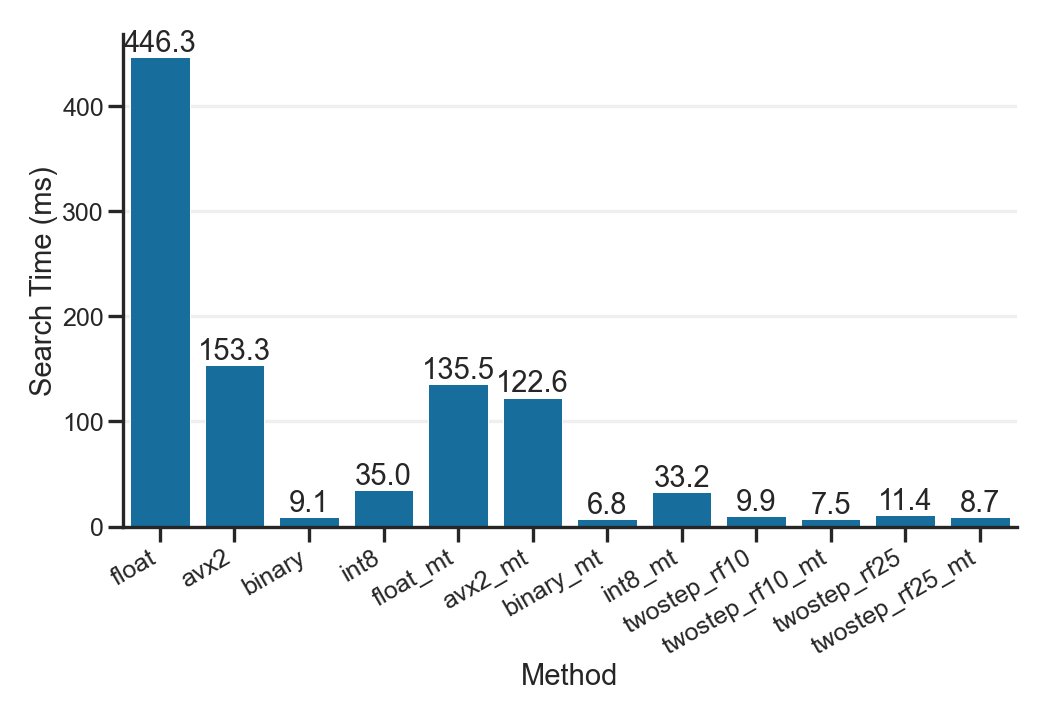

/var/folders/9k/j19m8qg14sz78bs76g1lv5y80000gn/T/ipykernel_75983/1896439042.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


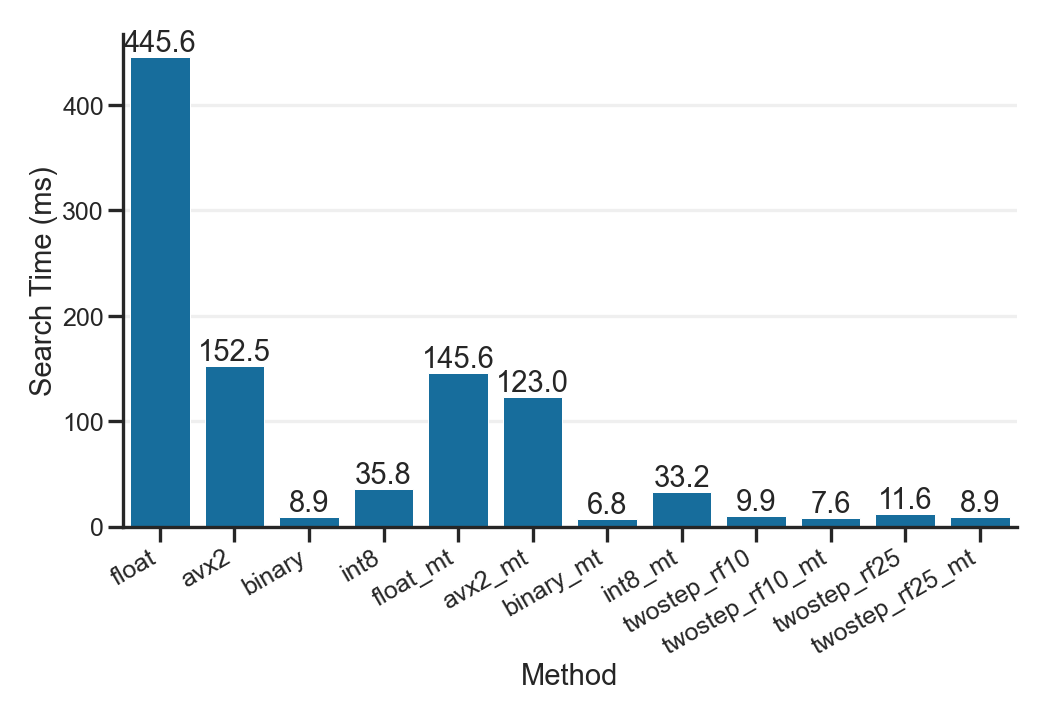

In [3]:
def plot_performance_comparison(results, result_key, skip_methods=None, enable_save_plot=False, name_postfix=""):
    if skip_methods is None:
        skip_methods = []
        
    summary = results[result_key]['summary']
    
    df = pd.DataFrame([
        {
            'Method': method,
            'Mean Time (ms)': stats['time_us']['mean'] / 1000,
            'Std Time': stats['time_us']['std'] / 1000
        }
        for method, stats in summary.items()
        #if method not in skip_methods
        if not any(fnmatch.fnmatch(method, pattern) for pattern in skip_methods)
    ])
    
    fig, ax = plt.subplots(figsize=[3.5, 2.4])
    
    bars = sns.barplot(data=df, x='Method', y='Mean Time (ms)', 
                      errorbar=('ci', 68), ax=ax)
    
    ax.set_xlabel('Method')
    ax.set_ylabel('Search Time (ms)')
    #ax.set_title('Search Performance Comparison')
    
    plt.xticks(rotation=30, ha='right')
    
    for bar in bars.containers[0]:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.1f}', ha='center', va='bottom', fontsize=7)
    
    plt.tight_layout()
    skipped_methods = ""
    for name in skip_methods:
        skipped_methods += name
    if enable_save_plot: save_plot(f'performance_comparison_{get_title_metadata(result_key=result_key, with_unterscores=True)}{name_postfix}')
    plt.show()

# Generate plot
#plot_performance_comparison(results, 'benchmark_dim1024_k100_q', skip_methods=['float', 'mf', 'float16', 'twostep_rf5', 'twostep_rf10', 'twostep_rf25', 'ts_mf_rf5', 'ts_mf_rf10', 'ts_mf_rf25'], enable_save_plot=True)
#plot_performance_comparison(results, 'benchmark_dim1024_k100_q', skip_methods=['float16'])
#plot_performance_comparison(results, 'benchmark_dim1024_k100_re', skip_methods=['float', 'mf', 'float16'])
#plot_performance_comparison(results, 'benchmark_dim1024_k100_re', skip_methods=['float16'])
#plot_performance_comparison(results, 'benchmark_dim768_k100_q', skip_methods=['float', 'mf', 'float16', 'twostep_rf5', 'twostep_rf10', 'twostep_rf25', 'ts_mf_rf5', 'ts_mf_rf10', 'ts_mf_rf25'], enable_save_plot=True)
#plot_performance_comparison(results, 'benchmark_results_1733419058', skip_methods=['float', 'mf', 'float16'])
plot_performance_comparison(results, 'benchmark_results_arm1', skip_methods=[], enable_save_plot=True)
plot_performance_comparison(results, 'benchmark_results_arm2', skip_methods=[], enable_save_plot=False)

/var/folders/9k/j19m8qg14sz78bs76g1lv5y80000gn/T/ipykernel_75983/205726494.py:61: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


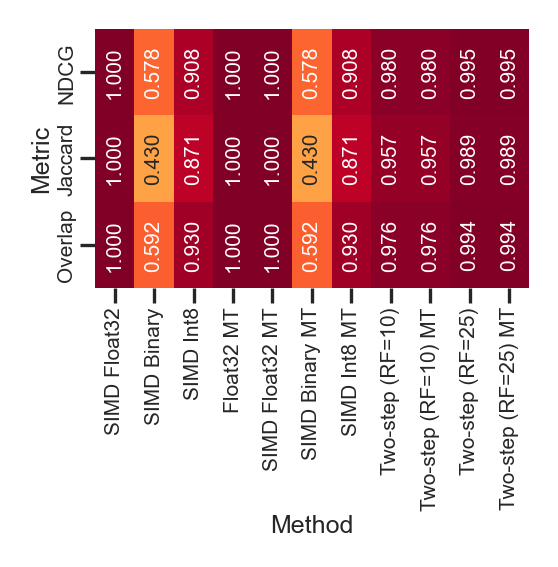

/var/folders/9k/j19m8qg14sz78bs76g1lv5y80000gn/T/ipykernel_75983/205726494.py:61: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Saved plot to images/accuracy_heatmap_transposed_dim1024_k100_q.png


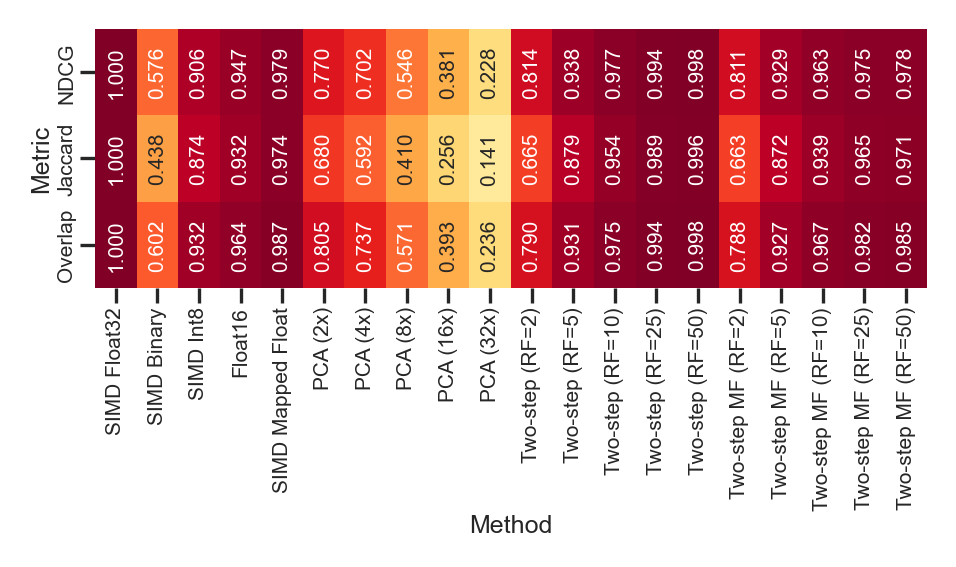

In [4]:
def plot_accuracy_heatmap_vert(results, result_key, only_methods=None, enable_save_plot=False, name_postfix="", method_names_map=None):
    """Create a heatmap showing accuracy metrics for different methods.
    
    Args:
        results: Dictionary containing benchmark results
        result_key: Key of the benchmark results to plot
        only_methods: List of method patterns to include (if None, include all except 'float')
        enable_save_plot: Whether to save the plot to disk
        name_postfix: Optional string to append to the filename
    """
    metrics = []
    
    # Use default method names if not provided
    if method_names_map is None:
        method_names_map = DEFAULT_METHOD_NAMES
    
    for method, stats in results[result_key]['summary'].items():
        if method != 'float' and (only_methods is None or any(fnmatch.fnmatch(method, pattern) for pattern in only_methods)):
            ndcg = stats.get('ndcg', {}).get('mean', 1.0)
            jaccard = stats.get('jaccard_index', {}).get('mean', 1.0)
            overlap = stats.get('overlap', {}).get('mean', results[result_key]['metadata']['k'])
            
            display_name = get_method_display_name(method, method_names_map)
            
            metrics.append({
                'Method': display_name,
                'NDCG': ndcg,
                'Jaccard': jaccard,
                'Overlap': overlap / results[result_key]['metadata']['k']
            })
    
    if not metrics:
        print("No valid metrics found to create heatmap")
        return
        
    df = pd.DataFrame(metrics).set_index('Method')
    
    # Transpose the dataframe to get methods on x-axis and metrics on y-axis
    df = df.T
    
    # Calculate appropriate figure width based on number of methods
    width = 0.175 * len(df.columns)
    height = 2.1  # Fixed height for 3 metrics
    
    fig, ax = plt.subplots(figsize=(width, height))
    
    # Create heatmap with transposed dataframe - removed colorbar
    sns.heatmap(df, annot=True, fmt='.3f', cmap='YlOrRd',
               vmin=0, vmax=1, center=0.5, ax=ax,
               annot_kws={'size': 5, 'rotation': 90},
               cbar=False)  # Set cbar=False to avoid layout engine conflict
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=90, fontsize=5)
    plt.yticks(fontsize=5)
    
    #ax.set_title('Accuracy Metrics Comparison', fontsize=7)
    ax.set_xlabel('Method', fontsize=6)
    ax.set_ylabel('Metric', fontsize=6)
    
    plt.tight_layout()
    
    if enable_save_plot:
        save_plot(f'accuracy_heatmap_transposed_{get_title_metadata(result_key=result_key, with_unterscores=True)}{name_postfix}')
    
    plt.show()
    
plot_accuracy_heatmap_vert(results, 'benchmark_results_arm1', enable_save_plot=False)
plot_accuracy_heatmap_vert(results, 'benchmark_dim1024_k100_q', enable_save_plot=True)

avx2
binary
int8
twostep_rf10
twostep_rf25
         Method      Display Name    Speedup      NDCG
0          avx2           Float32   2.911601  1.000000
1        binary            Binary  49.246660  0.578324
2          int8              Int8  12.738778  0.907518
3  twostep_rf10  Two-step (RF=10)  44.971833  0.979952
4  twostep_rf25  Two-step (RF=25)  39.222407  0.995077           Method      Display Name     Speedup      NDCG
0           avx2           Float32    8.280992  0.999993
1         binary            Binary  165.125902  0.583902
2           int8              Int8   11.610064  0.904795
3           pca2          PCA (/2)   14.874806  0.787850
4           pca4          PCA (/4)   28.489202  0.717683
5           pca8          PCA (/8)   48.903948  0.549457
6          pca16         PCA (/16)   86.466495  0.376163
7          pca32         PCA (/32)  142.835423  0.210294
8    twostep_rf2   Two-step (RF=2)  167.932370  0.824612
9   twostep_rf10  Two-step (RF=10)  167.707409  0.975262


/var/folders/9k/j19m8qg14sz78bs76g1lv5y80000gn/T/ipykernel_75983/1224844685.py:180: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


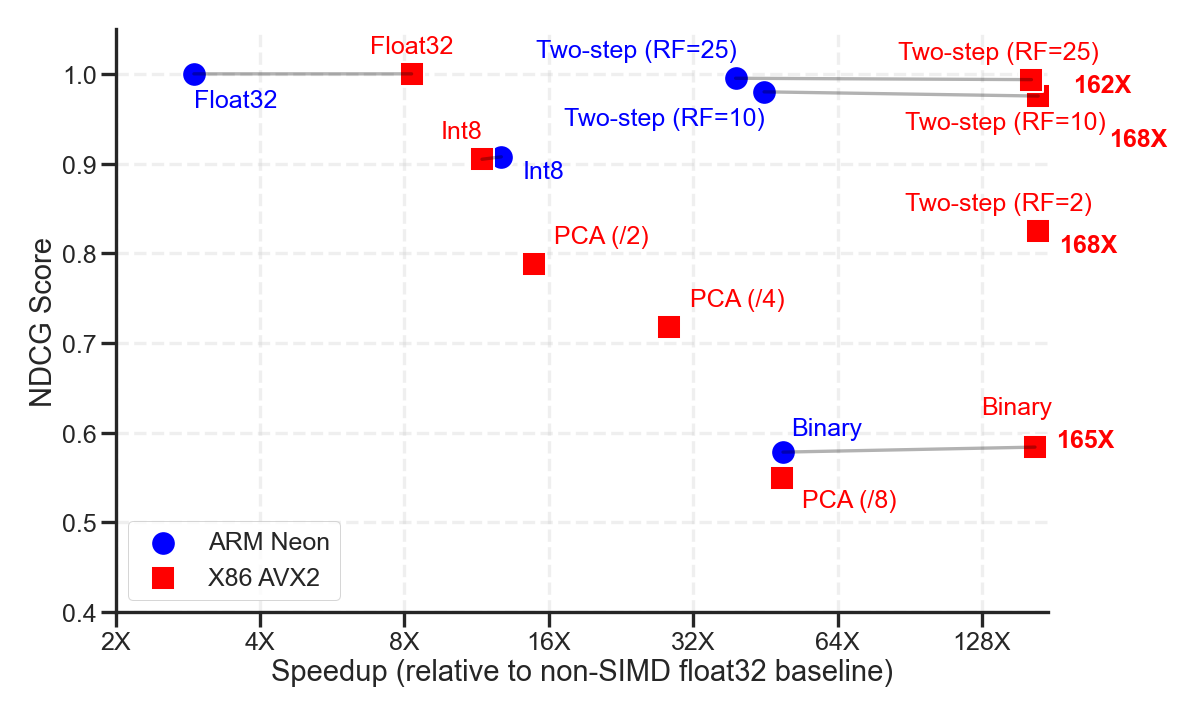

In [75]:
import matplotlib.ticker as ticker

def plot_pareto_frontier_comparison2(results, result_key1, result_key2, 
                                  skip_methods=None,
                                  method_names_map1=None, method_names_map2=None,
                                  label_offsets=None, special_methods=None, special_offsets=None,  # Added parameter for label offsets
                                  enable_save_plot=False, name_postfix=""):
    """Create a scatter plot comparing speed-accuracy trade-offs between two benchmarks.

    Args:
        results: Dictionary containing benchmark results
        result_key1: Key of the first benchmark
        result_key2: Key of the second benchmark
        skip_methods: List of method names to exclude
        method_names_map1: Dictionary mapping original method names to display names for first benchmark
        method_names_map2: Dictionary mapping original method names to display names for second benchmark
        label_offsets: Dictionary mapping method names to (x,y) offset tuples for label positioning
        enable_save_plot: Whether to save the plot
        name_postfix: Optional string to append to filename
    """
    if skip_methods is None:
        skip_methods = ['float_mt', 'int8_mt', 'binary_mt', 'avx2_mt']
    
    if method_names_map1 is None:
        method_names_map1 = {}
        
    if method_names_map2 is None:
        method_names_map2 = {}
        
    if label_offsets is None:
        label_offsets = {}
    
    # Default offsets if not specified in label_offsets
    default_offset1 = (5, -5)  # Default for benchmark 1
    default_offset2 = (5, 5)   # Default for benchmark 2
    
    summary1 = results[result_key1]['summary']
    summary2 = results[result_key2]['summary']
    
    # Get baseline (float) times for calculating speedup
    if 'float' in summary1:
        baseline_time1 = summary1['float']['time_us']['mean']
    else:
        print(f"Warning: 'float' method not found in {result_key1}. Using first method as baseline.")
        baseline_time1 = next(iter(summary1.values()))['time_us']['mean']
    
    if 'float' in summary2:
        baseline_time2 = summary2['float']['time_us']['mean']
    else:
        print(f"Warning: 'float' method not found in {result_key2}. Using first method as baseline.")
        baseline_time2 = next(iter(summary2.values()))['time_us']['mean']
    
    # Collect data points for both benchmarks
    data1 = []
    data2 = []
    
    # Methods present in both benchmarks for connecting lines
    common_methods = []
    
    # Process first benchmark
    for method, stats in summary1.items():
        if method not in skip_methods:
            # Calculate speedup relative to baseline
            speedup = baseline_time1 / stats['time_us']['mean']
            
            # Get display name for benchmark 1 or use original
            display_name = method_names_map1.get(method, method)
            
            data1.append({
                'Method': method,  # Keep original name internally
                'Display Name': display_name,  # Use for display
                'Speedup': speedup,
                'NDCG': stats.get('ndcg', {}).get('mean', 1.0)
            })
            
            # Check if this method is also in the second benchmark
            if method in summary2 and method not in skip_methods:
                common_methods.append(method)
    
    # Process second benchmark
    for method, stats in summary2.items():
        if method not in skip_methods:
            # Calculate speedup relative to baseline
            speedup = baseline_time2 / stats['time_us']['mean']
            
            # Get display name for benchmark 2 or use original
            display_name = method_names_map2.get(method, method)
            
            data2.append({
                'Method': method,  # Keep original name internally
                'Display Name': display_name,  # Use for display
                'Speedup': speedup,
                'NDCG': stats.get('ndcg', {}).get('mean', 1.0)
            })
    
    df1 = pd.DataFrame(data1)
    df2 = pd.DataFrame(data2)
    
    # Setup plot with a proper size
    fig, ax = plt.subplots(figsize=(4, 2.4))
    
    # Extract benchmark names for better labels
    benchmark1_name = result_key1.replace('benchmark_results_', '').replace('_', ' ').upper()
    benchmark2_name = result_key2.replace('benchmark_results_', '').replace('_', ' ').upper()
    
    # Create scatter plots with different markers
    scatter1 = sns.scatterplot(data=df1, x='Speedup', y='NDCG', 
                             color='blue', label="ARM Neon", marker='o',
                             s=35, ax=ax)
    
    scatter2 = sns.scatterplot(data=df2, x='Speedup', y='NDCG', 
                             color='red', label="X86 AVX2", marker='s',
                             s=35, ax=ax)
    
    # Add method labels next to points with custom offsets

    for _, row in df1.iterrows():
        method = row['Method']
        print(method)
        # Get custom offset if specified, otherwise use default
        offset = label_offsets.get(f"{method}_1", label_offsets.get(method, default_offset1))
        
        ax.annotate(row['Display Name'],
                  xy=(row['Speedup'], row['NDCG']),
                  xytext=offset,
                  textcoords='offset points',
                  color='blue',
                  fontsize=6)
    
    for _, row in df2.iterrows():
        method = row['Method']
        # Get custom offset if specified, otherwise use default
        offset = label_offsets.get(f"{method}_2", label_offsets.get(method, default_offset2))
        
        ax.annotate(row['Display Name'],
                  xy=(row['Speedup'], row['NDCG']),
                  xytext=offset,
                  textcoords='offset points',
                  color='red',
                  fontsize=6)

    for _, row in df2.iterrows():
        if row['Method'] in special_methods:
            # Get the offset for the method from the dictionary
            offset = special_offsets.get(row['Method'], (0, 12))
            ax.annotate(f"{int(round(row['Speedup']))}X",
                        xy=(row['Speedup'], row['NDCG']),
                        xytext=offset,
                        textcoords='offset points',
                        color='red',
                        fontsize=6,
                        fontweight='bold')
    print(df1, df2)
    # Draw connecting lines between matching methods
    for method in common_methods:
        # Find the method in both dataframes
        point1 = df1[df1['Method'] == method].iloc[0]
        point2 = df2[df2['Method'] == method].iloc[0]
        
        # Draw a line connecting the points
        ax.plot([point1['Speedup'], point2['Speedup']], 
               [point1['NDCG'], point2['NDCG']], 
               'k-', alpha=0.3, linewidth=0.8)
    
    # Set plot labels and title
    #ax.set_title('Speed-Accuracy Trade-off Comparison Between Benchmarks')
    ax.set_xlabel('Speedup (relative to non-SIMD float32 baseline)')
    ax.set_ylabel('NDCG Score')
    
    # Set axis limits
    ax.set_ylim(0.4, 1.05)
    ax.set_xlim(2, None)  # Start at 0.5x speedup to show potential slowdowns
    ax.set_xscale('log', base=2)  # Use log scale for speedup
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x)}X'))
    ax.legend(loc="lower left")
    
    # Add grid for better readability
    ax.grid(True, which='both', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    
    if enable_save_plot:
        save_plot(f'speedup_comparison_{benchmark1_name.replace(" ", "_")}_vs_{benchmark2_name.replace(" ", "_")}{name_postfix}')
    
    plt.show()

arm_method_names = {
    'float': 'Float32',
    'binary': 'Binary',
    'avx2': 'Float32',
    'int8': 'Int8',
    'twostep_rf2': 'Two-step (RF=2)',
    'twostep_rf5': 'Two-step (RF=5)',
    'twostep_rf10': 'Two-step (RF=10)',
    'twostep_rf25': 'Two-step (RF=25)',
    'twostep_rf50': 'Two-step (RF=50)',
    'twostep_rf2_mt': 'Two-step (RF=2) MT',
    'twostep_rf5_mt': 'Two-step (RF=5) MT',
    'twostep_rf10_mt': 'Two-step (RF=10) MT',
    'twostep_rf25_mt': 'Two-step (RF=25) MT',
    'ts_mf_rf2': 'Two-step MF (RF=2)',
    'ts_mf_rf5': 'Two-step MF (RF=5)',
    'ts_mf_rf10': 'Two-step MF (RF=10)',
    'ts_mf_rf25': 'Two-step MF (RF=25)',
    'ts_mf_rf50': 'Two-step MF (RF=50)',
    'mf': 'Mapped Float',
    'pca2': 'PCA (2x)',
    'pca4': 'PCA (4x)',
    'pca8': 'PCA (8x)',
    'pca16': 'PCA (16x)',
    'pca32': 'PCA (32x)',
}
avx_method_names = {
    'float': 'Float32',
    'binary': 'Binary',
    'avx2': 'Float32',
    'float16': 'Float16',
    'int8': 'Int8',
    'twostep_rf2': 'Two-step (RF=2)',
    'twostep_rf5': 'Two-step (RF=5)',
    'twostep_rf10': 'Two-step (RF=10)',
    'twostep_rf25': 'Two-step (RF=25)',
    'twostep_rf50': 'Two-step (RF=50)',
    'twostep_rf2_mt': 'Two-step (RF=2) MT',
    'twostep_rf5_mt': 'Two-step (RF=5) MT',
    'twostep_rf10_mt': 'Two-step (RF=10) MT',
    'twostep_rf25_mt': 'Two-step (RF=25) MT',
    'ts_mf_rf2': 'Two-step MF (RF=2)',
    'ts_mf_rf5': 'Two-step MF (RF=5)',
    'ts_mf_rf10': 'Two-step MF (RF=10)',
    'ts_mf_rf25': 'Two-step MF (RF=25)',
    'ts_mf_rf50': 'Two-step MF (RF=50)',
    'mf': 'Mapped Float',
    'pca2': 'PCA (/2)',
    'pca4': 'PCA (/4)',
    'pca8': 'PCA (/8)',
    'pca16': 'PCA (/16)',
    'pca32': 'PCA (/32)',
}
label_offsets = {
    'avx2_1': (0, -8),
    'mf_1': (-4, -8),
    'float16_1': (10, -8),
    'binary_1': (2, 4),
    'avx2_2': (-10, 5),
    'int8_2': (-10, 5),
    'pca8_2': (5, -7),
    'twostep_rf10_1': (-48, -8),
    'twostep_rf25_1': (-48, 5),
    'twostep_rf10_2': (-32, -8),
    'twostep_rf25_2': (-32, 5),
    'twostep_rf2_2': (-32, 5),
    'binary_2': (-13, 8),
}

# Define special offsets for individual methods
special_offsets = {
    "twostep_rf2": (5, -5),
    "twostep_rf10": (17, -12),
    "twostep_rf25": (10, -3),
    "binary": (5, 0)
}

# Define the set of special methods
special_methods = {"twostep_rf2", "twostep_rf10", "twostep_rf25", "binary"}

# Generate plot
plot_pareto_frontier_comparison2(results, 'benchmark_results_arm1', 'benchmark_dim1024_k25_q', method_names_map1=arm_method_names, method_names_map2=avx_method_names, enable_save_plot=True, skip_methods=['float','float_mt', 'float16', 'mf', 'ts_mf_rf2','ts_mf_rf5','ts_mf_rf10','ts_mf_rf25','ts_mf_rf50', 'int8_mt', 'avx2_mt', 'twostep_rf10_mt', 'twostep_rf25_mt', 'binary_mt', 'twostep_rf5', 'twostep_rf50'], label_offsets=label_offsets, special_methods = special_methods, special_offsets = special_offsets)
# plot_pareto_frontier_comparison2(results, 'benchmark_results_arm1', 'benchmark_dim1024_k25_q', method_names_map1=arm_method_names, method_names_map2=avx_method_names, enable_save_plot=True, skip_methods=['float','float_mt', 'ts_mf_rf2','ts_mf_rf5','ts_mf_rf10','ts_mf_rf25','ts_mf_rf50', 'int8_mt', 'avx2_mt', 'twostep_rf10_mt', 'twostep_rf25_mt', 'binary_mt', 'twostep_rf5', 'twostep_rf50'], label_offsets=label_offsets)

#plot_pareto_frontier_comparison2(results, 'benchmark_results_arm1', 'benchmark_dim1024_k25_q', enable_save_plot=False, skip_methods=['float','float_mt', 'float16', 'mf', 'ts_mf_rf2','ts_mf_rf5','ts_mf_rf10','ts_mf_rf25','ts_mf_rf50', 'int8_mt', 'avx2_mt', 'twostep_rf10_mt', 'twostep_rf25_mt', 'binary_mt'])

Saved plot to images/memory_vs_accuracy_results_arm1.png


/var/folders/9k/j19m8qg14sz78bs76g1lv5y80000gn/T/ipykernel_75983/1063577763.py:50: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


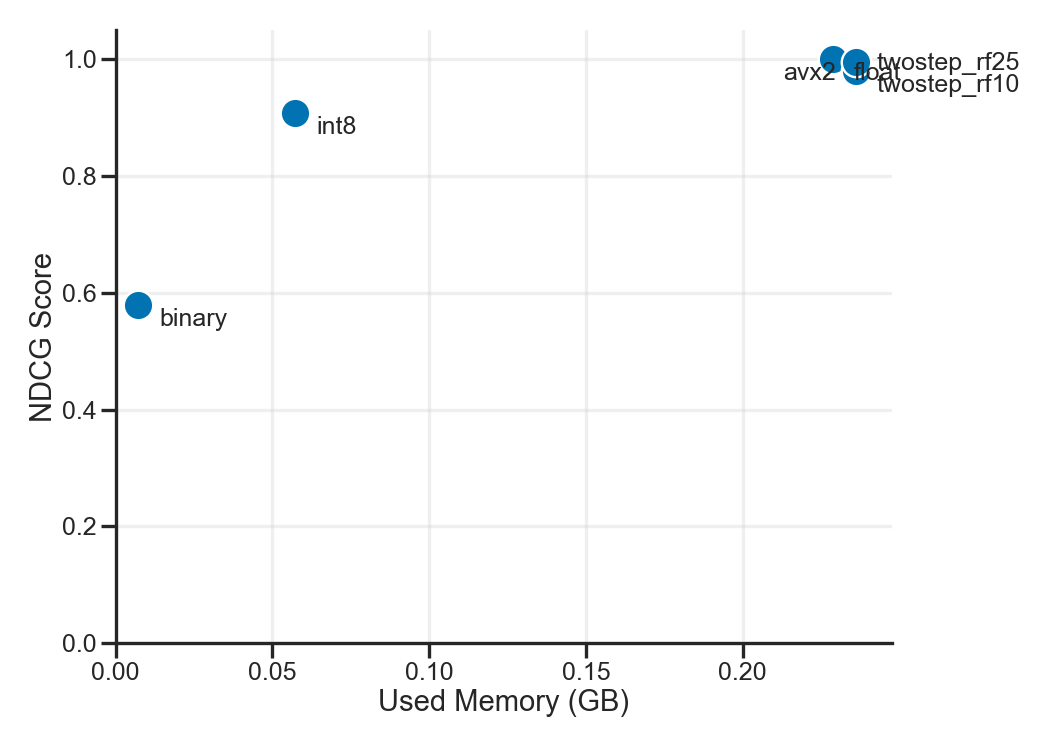

/var/folders/9k/j19m8qg14sz78bs76g1lv5y80000gn/T/ipykernel_75983/1063577763.py:50: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


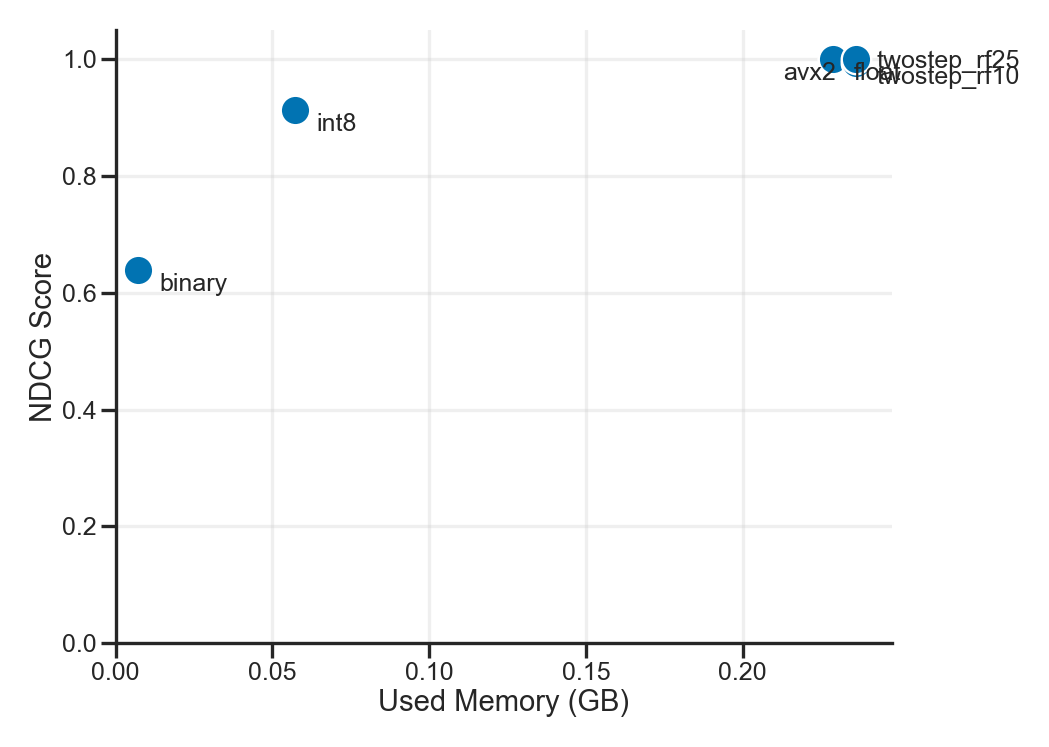

In [6]:
def plot_pareto_frontier_memory(results, result_key, skip_methods = ['float'], enable_save_plot=False, name_postfix=""):
    """Create a scatter plot showing the trade-off between memory and accuracy.

    Args:
        results: Dictionary containing benchmark results
        result_key: Key of the benchmark results to plot
        skip_methods: List of method names to exclude
    """
    summary = results[result_key]['summary']
    num_vectors = results[result_key]['metadata']['num_vectors']
    vector_dim = results[result_key]['metadata']['vector_dim']
    
    # Collect data points
    data = []
    for method, stats in summary.items():
        if method not in skip_methods:
            data.append({
                'Method': method,
                'Memory (GB)': calculate_method_memory(method, num_vectors, vector_dim)/1024/1024/1024,
                'NDCG': stats.get('ndcg', {}).get('mean', 1.0)
            })
    
    df = pd.DataFrame(data)

    fig, ax = plt.subplots()
    
    # Create scatter plot
    sns.scatterplot(data=df, x='Memory (GB)', y='NDCG', s=50)
    
    # Add method labels next to points
    for _, row in df.iterrows():
        if(row['Method'] == 'twostep_rf25'): textpos = (5, -2)
        elif(row['Method'] == 'twostep_rf50'): textpos = (5, 3)
        elif row['Method'] in ['avx2', 'mf']: textpos = (-12,-5)
        else: textpos = (5, -5)
        ax.annotate(row['Method'], 
                   (row['Memory (GB)'], row['NDCG']),
                   xytext=textpos, 
                   textcoords='offset points',
                   fontsize=6)
    
    #ax.set_title('Memory-Accuracy Trade-off Analysis')
    ax.set_xlabel('Used Memory (GB)')
    ax.set_ylabel('NDCG Score')
    
    # Ensure NDCG axis starts at 0
    ax.set_ylim(0, 1.05)
    ax.set_xlim(0)
    
    plt.tight_layout()
    if enable_save_plot: save_plot(f'memory_vs_accuracy_{get_title_metadata(result_key=result_key, with_unterscores=True)}{name_postfix}')
    plt.show()

# Generate plot
# plot_pareto_frontier_memory(results, 'benchmark_dim1024_k100_q', skip_methods=['float', 'ts_mf_rf5', 'ts_mf_rf10', '_ts_mf_rf25', 'ts_mf_rf50'], enable_save_plot=True)
# plot_pareto_frontier_memory(results, 'benchmark_dim1024_k100_re', skip_methods=['float'])
# plot_pareto_frontier_memory(results, 'benchmark_results_1733419058', skip_methods=['float', 'ts_mf_rf5', 'ts_mf_rf10', '_ts_mf_rf25', 'ts_mf_rf50'])
plot_pareto_frontier_memory(results, 'benchmark_results_arm1', skip_methods=['float_mt', 'int8_mt', 'binary_mt', 'avx2_mt', 'twostep_rf10_mt', 'twostep_rf25_mt'], enable_save_plot=True)
plot_pareto_frontier_memory(results, 'benchmark_results_arm2', skip_methods=['float_mt', 'int8_mt', 'binary_mt', 'avx2_mt', 'twostep_rf10_mt', 'twostep_rf25_mt'], enable_save_plot=False)

Saved plot to images/twostep_comparison_combined_benchmark_dim1024_k100_q_mf.png


/var/folders/9k/j19m8qg14sz78bs76g1lv5y80000gn/T/ipykernel_75983/2879701504.py:64: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


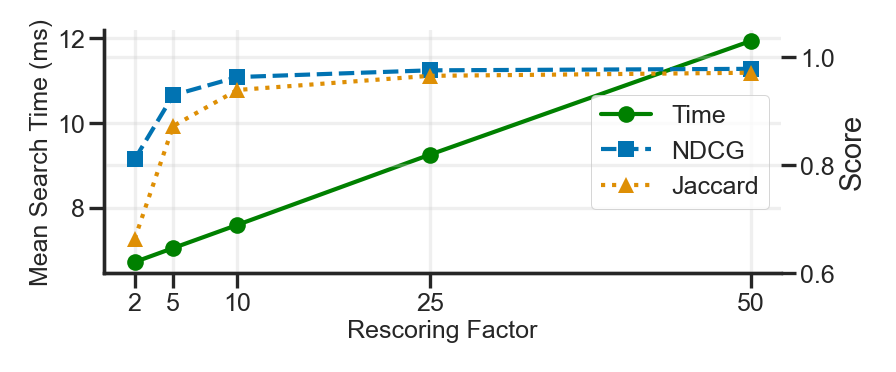

In [7]:
def plot_twostep_comparison_combined(results, result_key, show_method='twostep_rf', skip_methods=[], enable_save_plot=False, name_postfix=""):
    """Plot combined comparison of time and quality metrics for twostep methods.
    
    Creates a single plot with dual y-axes showing:
    - Search time vs rescoring factor (left axis)
    - Search quality (NDCG and Jaccard) vs rescoring factor (right axis)
    
    Args:
        results: Dictionary containing benchmark results
        result_key: Key of the benchmark results to plot
    """
    # Get twostep methods
    twostep_methods = [m for m in results[result_key]['summary'].keys() 
                      if m.startswith(show_method)]
    
    if not twostep_methods:
        print("No twostep methods found in results")
        return
    
    # Collect data
    data = []
    for method in twostep_methods:
        if method not in skip_methods:
            rf = int(method.replace(show_method, ''))
            stats = results[result_key]['summary'][method]
            data.append({
                'Rescoring Factor': rf,
                'Mean Time (ms)': stats['time_us']['mean'] / 1000,
                'Mean NDCG': stats.get('ndcg', {}).get('mean', 1.0),
                'Jaccard Index': stats.get('jaccard_index', {}).get('mean', 1.0)
            })
        
    df = pd.DataFrame(data).sort_values('Rescoring Factor')
    
    # Create figure with two y-axes
    fig, ax1 = plt.subplots(figsize=(3, 1.25))
    ax2 = ax1.twinx()
    
    # Plot time on left axis
    line1 = ax1.plot(df['Rescoring Factor'], df['Mean Time (ms)'], 
                     marker='o', label='Time', color='green')
    ax1.set_xlabel('Rescoring Factor', fontsize=6)
    ax1.set_ylabel('Mean Search Time (ms)', fontsize=6)
    
    # Plot quality metrics on right axis
    line2 = ax2.plot(df['Rescoring Factor'], df['Mean NDCG'], 
                     marker='s', linestyle='--', label='NDCG')
    line3 = ax2.plot(df['Rescoring Factor'], df['Jaccard Index'], 
                     marker='^', linestyle=':', label='Jaccard')
    ax2.set_ylabel('Score')
    
    # Set y-axis limits for scores
    ax2.set_ylim(0.6, 1.05)
    
    # Ensure x-axis shows all integer rescoring factors
    ax1.set_xticks(df['Rescoring Factor'])
    
    # Add combined legend
    lines = line1 + line2 + line3
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='center right')
    
    #plt.title('Twostep Method Performance' + ' ' + show_method)
    plt.tight_layout()
    
    if enable_save_plot: save_plot(f'twostep_comparison_combined_{result_key}{name_postfix}')
    plt.show()

# Example usage
# plot_twostep_comparison(results_dict, 'benchmark_results_example')
#plot_twostep_comparison_combined(results, 'benchmark_dim1024_k100_q', enable_save_plot=True)
plot_twostep_comparison_combined(results, 'benchmark_dim1024_k100_q', show_method='ts_mf_rf', enable_save_plot=True, name_postfix="_mf")
#plot_twostep_comparison_combined(results, 'benchmark_dim1024_k25_q')
#plot_twostep_comparison_combined(results, 'benchmark_results_1733419058')
#plot_twostep_comparison_combined(results, 'benchmark_results_1733419058', show_method='ts_mf_rf')
#plot_twostep_comparison_combined(results, 'benchmark_results_arm1', enable_save_plot=True, show_method='twostep_rf', skip_methods=['twostep_rf10_mt', 'twostep_rf25_mt'])

/var/folders/9k/j19m8qg14sz78bs76g1lv5y80000gn/T/ipykernel_75983/3818229937.py:73: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Saved plot to images/ndcg_boxplots_results_arm1.png


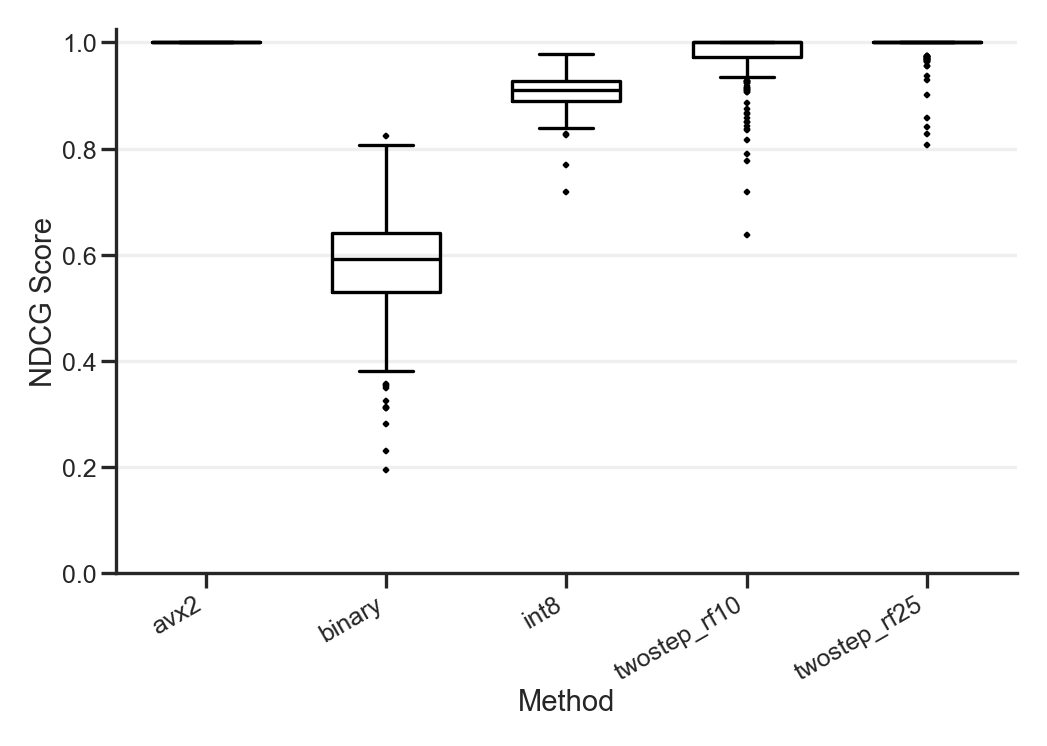


NDCG Statistical Summary:
              count    mean     std     min     25%     50%     75%    max
Method                                                                    
avx2          313.0  1.0000  0.0000  1.0000  1.0000  1.0000  1.0000  1.000
binary        313.0  0.5783  0.0985  0.1950  0.5291  0.5920  0.6418  0.824
int8          313.0  0.9075  0.0301  0.7184  0.8890  0.9104  0.9272  0.977
twostep_rf10  313.0  0.9800  0.0446  0.6381  0.9728  1.0000  1.0000  1.000
twostep_rf25  313.0  0.9951  0.0216  0.8069  1.0000  1.0000  1.0000  1.000


/var/folders/9k/j19m8qg14sz78bs76g1lv5y80000gn/T/ipykernel_75983/3818229937.py:73: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Saved plot to images/jaccard_boxplots_results_arm1.png


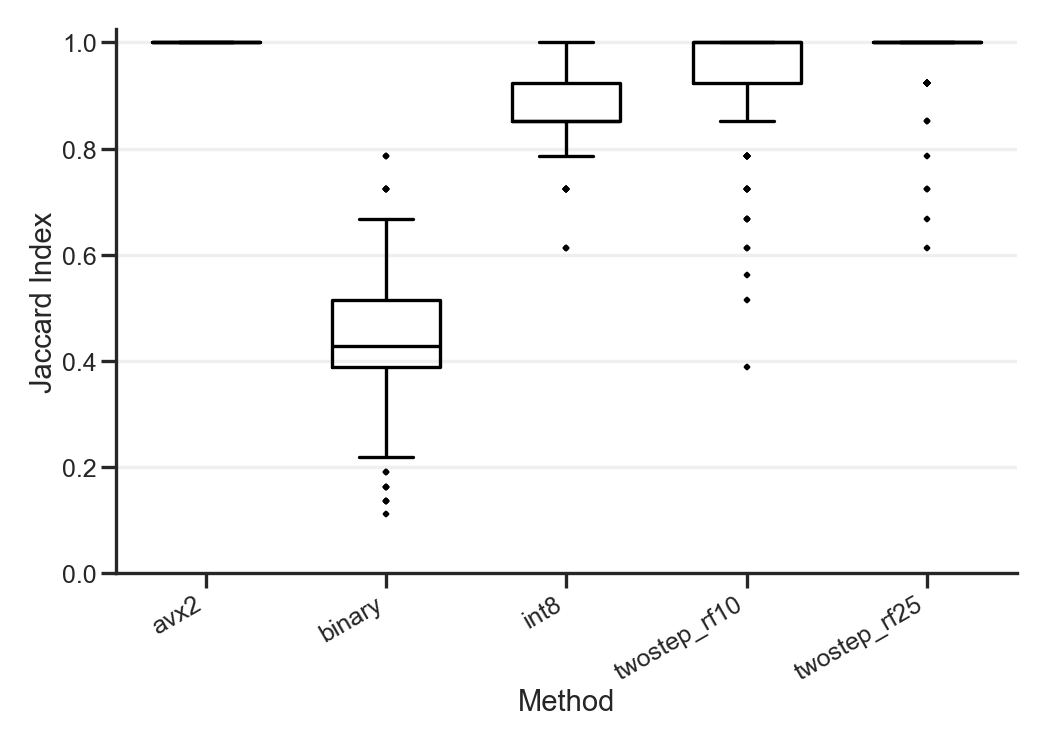


Jaccard Index Statistical Summary:
              count    mean     std     min     25%     50%     75%     max
Method                                                                     
avx2          313.0  1.0000  0.0000  1.0000  1.0000  1.0000  1.0000  1.0000
binary        313.0  0.4297  0.1136  0.1111  0.3889  0.4286  0.5152  0.7857
int8          313.0  0.8709  0.0641  0.6129  0.8519  0.8519  0.9231  1.0000
twostep_rf10  313.0  0.9569  0.0875  0.3889  0.9231  1.0000  1.0000  1.0000
twostep_rf25  313.0  0.9894  0.0433  0.6129  1.0000  1.0000  1.0000  1.0000


In [8]:
def plot_metric_boxplots(results, result_key, metric='ndcg', skip_methods=None, enable_save_plot=False, name_postfix=""):
    """Create box plots for NDCG or Jaccard Index distributions.
    
    Args:
        results: Dictionary containing benchmark results
        result_key: Key of the benchmark results to plot
        metric: Which metric to plot ('ndcg' or 'jaccard')
        skip_methods: List of method names to skip in the plot
    """
    if skip_methods is None:
        skip_methods = []
        
    # Configure based on metric
    metric_config = {
        'ndcg': {'key': 'ndcg', 'title': 'NDCG', 'ylabel': 'NDCG Score'},
        'jaccard': {'key': 'jaccard_index', 'title': 'Jaccard Index', 'ylabel': 'Jaccard Index'}
    }
    
    if metric not in metric_config:
        raise ValueError(f"Metric must be one of {list(metric_config.keys())}")
    
    config = metric_config[metric]
    
    # Collect metric data from each run
    plot_data = []
    methods = []
    
    for run in results[result_key]['runs']:
        for search in run['searches']:
            method = search['method']
            if method != 'float' and not any(fnmatch.fnmatch(method, pattern) for pattern in skip_methods):
                if method not in methods: methods.append(method)
                try:
                    metrics = search['metrics']
                    value = metrics[config['key']]
                    plot_data.append({
                        'Method': method,
                        'Value': value
                    })
                except KeyError:
                    print(f"Warning: Missing {config['key']} metric for method {method}")
                    continue
    
    if not plot_data:
        print(f"No valid {metric} data found to plot")
        return
        
    df = pd.DataFrame(plot_data)
    
    plt.figure()
    
    # Create boxplot
    sns.boxplot(data=df, x='Method', y='Value',
                showfliers=True,
                width=0.6,
                linewidth=0.8,
                fliersize=1.0,
                fill=False,
                flierprops={"marker": "x", 'markerfacecolor': 'black', 'markeredgecolor': 'black'},
                boxprops={'color': 'black'},  # Set box color to black
                whiskerprops={'color': 'black'},  # Match whisker color
                medianprops={'color': 'black'},  # Match median line color
                capprops={'color': 'black'},
                notch=False)
    
    # Customize plot
    plt.xticks(rotation=30, ha='right')
    #plt.title(f'{config["title"]} Score Distributions')
    plt.ylabel(config['ylabel'])
    plt.xlabel('Method')
    plt.ylim(0, 1.025)  # Both metrics are between 0 and 1
    
    plt.tight_layout()
    
    # Save plot if enabled
    if enable_save_plot: save_plot(f'{metric}_boxplots_{get_title_metadata(result_key=result_key, with_unterscores=True)}{name_postfix}')
    
    plt.show()
    
    # Print statistical summary
    print(f"\n{config['title']} Statistical Summary:")
    summary = df.groupby('Method')['Value'].describe()
    print(summary.round(4).to_string())

# Generate plots
# plot_metric_boxplots(results, 'benchmark_dim1024_k100_q', metric='ndcg', skip_methods=['ts_mf*', 'twostep_rf*'], enable_save_plot=True)
# plot_metric_boxplots(results, 'benchmark_dim1024_k100_q', metric='jaccard', skip_methods=['ts_mf*', 'twostep_rf*'], enable_save_plot=True)
# plot_metric_boxplots(results, 'benchmark_dim1024_k100_q', metric='ndcg', skip_methods=['avx2', 'binary', 'int8', 'float16', 'mf', 'pca*'], name_postfix="_twostep", enable_save_plot=True)
# plot_metric_boxplots(results, 'benchmark_dim1024_k100_q', metric='jaccard', skip_methods=['avx2', 'binary', 'int8', 'float16', 'mf', 'pca*'], name_postfix="_twostep", enable_save_plot=True)

# plot_metric_boxplots(results, 'benchmark_dim1024_k100_re', metric='ndcg', skip_methods=['ts_mf*', 'twostep_rf*'], enable_save_plot=True)
# plot_metric_boxplots(results, 'benchmark_dim1024_k100_re', metric='jaccard', skip_methods=['ts_mf*', 'twostep_rf*'], enable_save_plot=True)
# plot_metric_boxplots(results, 'benchmark_dim1024_k100_re', metric='ndcg', skip_methods=['avx2', 'binary', 'int8', 'float16', 'mf', 'pca*'], name_postfix="_twostep", enable_save_plot=True)
# plot_metric_boxplots(results, 'benchmark_dim1024_k100_re', metric='jaccard', skip_methods=['avx2', 'binary', 'int8', 'float16', 'mf', 'pca*'], name_postfix="_twostep", enable_save_plot=True)
#plot_metric_boxplots(results, 'benchmark_dim1024_k10_q', metric='ndcg', skip_methods=['ts_mf*', 'twostep_rf*'])
plot_metric_boxplots(results, 'benchmark_results_arm1', metric='ndcg', skip_methods=['*mt'], enable_save_plot=True)
plot_metric_boxplots(results, 'benchmark_results_arm1', metric='jaccard', skip_methods=['*mt'], enable_save_plot=True)
#plot_metric_boxplots(results, 'benchmark_results_arm2', metric='jaccard', skip_methods=['*mt'])

In [76]:
def plot_memory_bandwidth(results_dict, result_key, skip_methods=[], enable_save_plot=False, name_postfix=""):
    """Calculate and plot approximate memory bandwidth for each method.
    
    Args:
        results_dict: Dictionary containing benchmark results
        result_key: Key of the benchmark results to plot
    """
    results = results_dict[result_key]
    num_vectors = results['metadata']['num_vectors']
    vector_dim = results['metadata']['vector_dim']
    k = results['metadata']['k']
    
    # Collect bandwidth data
    bandwidth_data = []
    
    for method, stats in results['summary'].items():
        if method not in skip_methods:
            time_seconds = stats['time_us']['mean'] / 1_000_000  # Convert microseconds to seconds
            memory_bytes = calculate_bandwidth_memory(method, num_vectors, vector_dim, k)
            
            # Calculate bandwidth in GB/s
            bandwidth = (memory_bytes / (1024 * 1024 * 1024)) / time_seconds
            
            bandwidth_data.append({
                'Method': format_method_name(method),
                'Bandwidth (GB/s)': bandwidth,
                'Memory (GB)': memory_bytes / (1024 * 1024 * 1024),
                'Time (ms)': stats['time_us']['mean'] / 1000
            })
    
    df = pd.DataFrame(bandwidth_data)

    plt.figure()
    bars = plt.bar(df['Method'], df['Bandwidth (GB/s)'])
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom',
                fontsize=5)
    
    #plt.title('Approximate Memory Bandwidth by Method')
    plt.xlabel('Method')
    plt.ylabel('Bandwidth (GB/s)')
    plt.xticks(rotation=30, ha='right')
    
    plt.tight_layout()
    if enable_save_plot: save_plot(f'memory_bandwidth_{result_key}{name_postfix}')
    plt.show()
    
    # Print detailed statistics
    print("\nDetailed Bandwidth Analysis:")
    print("\nMethod Statistics:")
    stats_df = df.sort_values('Bandwidth (GB/s)', ascending=False)
    print(stats_df.round(2).to_string(index=False))
    
    # Calculate relative bandwidth compared to float
    float_bandwidth = df[df['Method'] == 'float']['Bandwidth (GB/s)'].iloc[0]
    print("\nRelative Bandwidth (compared to float):")
    for _, row in df.iterrows():
        relative = row['Bandwidth (GB/s)'] / float_bandwidth
        print(f"{row['Method']:15} {relative:.2f}x")


# Example usage
# plot_memory_bandwidth(results, 'benchmark_dim1024_k100_re', ['float16'])
# plot_memory_bandwidth(results, 'benchmark_dim1024_k100_q', ['float16'])
# plot_memory_bandwidth(results, 'benchmark_dim1024_k100_q', ['float16', 'twostep_rf5', 'twostep_rf10', 'twostep_rf25', 'ts_mf_rf5', 'ts_mf_rf10', 'ts_mf_rf25'], enable_save_plot=True)
# plot_memory_bandwidth(results, 'benchmark_dim768_k100_q', ['float16', 'twostep_rf5', 'twostep_rf10', 'twostep_rf25', 'ts_mf_rf5', 'ts_mf_rf10', 'ts_mf_rf25'], enable_save_plot=True)
# plot_memory_bandwidth(results, 'benchmark_results_1733419058', ['float16'])
plot_memory_bandwidth(results, 'benchmark_results_arm1', skip_methods=['float_mt', 'int8_mt', 'binary_mt', 'avx2_mt', 'twostep_rf10_mt', 'twostep_rf25_mt'], enable_save_plot=True)
# plot_memory_bandwidth(results, 'benchmark_results_arm2', skip_methods=['float_mt', 'int8_mt', 'binary_mt', 'avx2_mt', 'twostep_rf10_mt', 'twostep_rf25_mt'])
plot_memory_bandwidth(results, 'benchmark_results_arm1', skip_methods=['twostep_rf10_mt', 'twostep_rf25_mt'], enable_save_plot=False)
# plot_memory_bandwidth(results, 'benchmark_results_arm2', skip_methods=['twostep_rf10_mt', 'twostep_rf25_mt'])

NameError: name 'format_method_name' is not defined

In [ ]:
def show_summary(results, result_key, skip_methods=[]):
    results_data = results[result_key]
    num_vectors = results_data['metadata']['num_vectors']
    vector_dim = results_data['metadata']['vector_dim']
    k = results_data['metadata']['k']
    
    summary_data = []
    
    for method, stats in results_data['summary'].items():
        if method in skip_methods:
            continue
            
        # Basic metrics
        method_data = {
            'Method': method,
            'Mean Time (ms)': stats['time_us']['mean'] / 1000,
            'Std Time': stats['time_us']['std'] / 1000,
            'NDCG': stats.get('ndcg', {}).get('mean', 1.0),
            'Jaccard': stats.get('jaccard_index', {}).get('mean', 1.0),
            'Overlap': stats.get('overlap', {}).get('mean', results_data['metadata']['k']),
            'Memory (GB)': calculate_method_memory(method, num_vectors, vector_dim) / (1024**3),
            'Bandw. (GB/s)': (calculate_bandwidth_memory(method, num_vectors, vector_dim, k) / (stats['time_us']['mean'] * 10**-6)) / (1024**3)
        }
        
        # Add power statistics if available
        if 'power_measurements' in results_data and method in results_data['power_measurements']:
            power_stats = results_data['power_measurements'][method]['summary']
            avg_time_s = stats['time_us']['mean'] / 1_000_000  # seconds
            
            method_data.update({
                'Avg Power (W)': power_stats['avg_power'],
                'Energy/Query (J)': power_stats['avg_power'] * avg_time_s,
                'Queries/Joule': 1 / (power_stats['avg_power'] * avg_time_s) if avg_time_s > 0 else 0
            })
        
        summary_data.append(method_data)
    
    summary_df = pd.DataFrame(summary_data)
    
    # Display results
    display(Markdown(f"## Summary for {result_key}"))
    display(Markdown("### Metadata"))
    display(Markdown("```json\n" + json.dumps(results_data['metadata'], indent=2) + "\n```"))
    
    # Check if power measurements exist
    if 'power_measurements' in results_data:
        display(Markdown("### Results (including power measurements)"))
    else:
        display(Markdown("### Results (no power measurements available)"))
        
    display(summary_df.round(4))
    
    # If power measurements exist, display a summary of them
    if 'power_measurements' in results_data:
        # Create a subset DataFrame with just the power-related metrics for easier viewing
        power_cols = ['Method', 'Mean Time (ms)', 'NDCG', 'Avg Power (W)', 'Energy/Query (J)', 'Queries/Joule']
        power_cols = [col for col in power_cols if col in summary_df.columns]
        
        if len(power_cols) > 1:  # If we have power metrics beyond just 'Method'
            display(Markdown("### Power Efficiency Summary"))
            display(summary_df[power_cols].sort_values('Energy/Query (J)').round(4))

# Usage:
show_summary(results, 'benchmark_results_arm1', skip_methods=['twostep_rf10_mt', 'twostep_rf25_mt'])
show_summary(results, 'benchmark_results_arm2', skip_methods=['twostep_rf10_mt', 'twostep_rf25_mt'])

In [ ]:
def plot_power_dots_over_time(results, result_key, methods=None, skip_methods=None, enable_save_plot=False, name_postfix=""):
    """Create a scatter plot showing power measurements as dots over time.
    
    Args:
        results: Dictionary containing benchmark results
        result_key: Key of the benchmark results to plot
        methods: List of specific methods to include (if None, include all)
        skip_methods: List of methods to exclude
        enable_save_plot: Whether to save the plot to disk
        name_postfix: Optional string to append to the filename
    """
    if skip_methods is None:
        skip_methods = []
        
    if 'power_measurements' not in results[result_key]:
        print(f"No power measurements found in {result_key}")
        return
        
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Track methods for legend
    plot_methods = []
    
    for method, measurements in results[result_key]['power_measurements'].items():
        if (methods is None or method in methods) and not any(fnmatch.fnmatch(method, pattern) for pattern in skip_methods):
            if 'raw' not in measurements:
                continue
                
            power_data = measurements['raw']
            interval = power_data.get('interval', 1)  # Default to 1s if not specified
            times = [i * interval for i in range(len(power_data['power']))]
            
            # Plot power as dots
            ax.scatter(times, power_data['power'], s=10, alpha=0.3, label=method)
            plot_methods.append(method)
    
    if not plot_methods:
        print("No data to plot after filtering methods")
        return
    
    # Add title and labels
    #ax.set_title('Power Consumption Over Time')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Power (W)')
    
    # Add legend with smaller font
    ax.legend(fontsize='small', loc='best')
    
    # Add grid for better readability
    ax.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    
    if enable_save_plot:
        save_plot(f'power_dots_{get_title_metadata(result_key=result_key, with_unterscores=True)}{name_postfix}')
    
    plt.show()


def plot_power_heatmap(results, result_key, skip_methods=None, enable_save_plot=False, name_postfix=""):
    """Create a heatmap of power measurements across methods and time.
    
    Args:
        results: Dictionary containing benchmark results
        result_key: Key of the benchmark results to plot
        skip_methods: List of methods to exclude
        enable_save_plot: Whether to save the plot to disk
        name_postfix: Optional string to append to the filename
    """
    if skip_methods is None:
        skip_methods = []
        
    if 'power_measurements' not in results[result_key]:
        print(f"No power measurements found in {result_key}")
        return
    
    # Collect power data for all methods
    power_data = {}
    max_length = 0
    
    for method, measurements in results[result_key]['power_measurements'].items():
        if not any(fnmatch.fnmatch(method, pattern) for pattern in skip_methods):
            if 'raw' not in measurements:
                continue
                
            raw_data = measurements['raw']
            power_data[method] = raw_data['power']
            max_length = max(max_length, len(raw_data['power']))
    
    if not power_data:
        print("No data to plot after filtering methods")
        return
    
    # Create a matrix for the heatmap
    methods = list(power_data.keys())
    
    # Pad all power data arrays to the same length
    heat_data = np.zeros((len(methods), max_length))
    for i, method in enumerate(methods):
        data = power_data[method]
        heat_data[i, :len(data)] = data
    
    # Create the heatmap
    fig, ax = plt.subplots(figsize=(12, len(methods) * 0.5 + 2))
    
    # Get time interval from the first method
    interval = results[result_key]['power_measurements'][methods[0]]['raw'].get('interval', 1)
    
    # Create time points
    time_points = [i * interval for i in range(max_length)]
    
    # Plot heatmap with custom colormap
    im = ax.imshow(heat_data, cmap='viridis', aspect='auto', interpolation='none')
    
    # Add colorbar
    #cbar = ax.figure.colorbar(im, ax=ax)
    #cbar.set_label('Power (W)')
    
    # Configure axes
    ax.set_yticks(np.arange(len(methods)))
    ax.set_yticklabels(methods)
    
    # Set x-axis ticks to show time in seconds at reasonable intervals
    max_ticks = 20
    tick_step = max(1, max_length // max_ticks)
    tick_positions = np.arange(0, max_length, tick_step)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([f"{t:.1f}" for t in np.array(time_points)[tick_positions]])
    
    # Add title and labels
    ax.set_title('Power Consumption Heatmap')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Method')
    
    plt.tight_layout()
    
    if enable_save_plot:
        save_plot(f'power_heatmap_{get_title_metadata(result_key=result_key, with_unterscores=True)}{name_postfix}')
    
    plt.show()
    
plot_power_dots_over_time(results, 'benchmark_results_arm1', methods=['float', 'binary', 'int8', 'avx2', 'twostep_rf10'], enable_save_plot=True)
plot_power_heatmap(results, 'benchmark_results_arm1', skip_methods=['float_mt', 'binary_mt', 'int8_mt', 'avx2_mt', 'twostep_rf10_mt', 'twostep_rf25_mt'], enable_save_plot=True)

In [ ]:
def plot_power_comparison(results, result_key, skip_methods=None, enable_save_plot=False, name_postfix=""):
    """Create bar chart comparing average power consumption across methods.
    
    Args:
        results: Dictionary containing benchmark results
        result_key: Key of the benchmark results to plot
        skip_methods: List of method names to exclude from comparison
        enable_save_plot: Whether to save the plot to disk
        name_postfix: Optional string to append to the filename
    """
    if skip_methods is None:
        skip_methods = []
        
    if 'power_measurements' not in results[result_key]:
        print(f"No power measurements found in {result_key}")
        return
        
    # Collect power data
    power_data = []
    for method, measurements in results[result_key]['power_measurements'].items():
        if not any(fnmatch.fnmatch(method, pattern) for pattern in skip_methods):
            power_data.append({
                'Method': method,
                'Average Power (W)': measurements['summary']['avg_power']
            })
    
    if not power_data:
        print("No data to plot after filtering methods")
        return
        
    df = pd.DataFrame(power_data)
    
    # Sort by power consumption
    df = df.sort_values('Average Power (W)', ascending=False)
    
    fig, ax = plt.subplots()
    
    bars = sns.barplot(data=df, x='Method', y='Average Power (W)', 
                     errorbar=None, ax=ax)
    
    ax.set_xlabel('Method')
    ax.set_ylabel('Average Power (W)')
    #ax.set_title('Power Consumption Comparison')
    
    plt.xticks(rotation=30, ha='right')
    
    # Add value labels on top of bars
    for bar in bars.containers[0]:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
              f'{height:.2f}', ha='center', va='bottom', fontsize=7)
    
    plt.tight_layout()
    
    if enable_save_plot:
        save_plot(f'power_comparison_{get_title_metadata(result_key=result_key, with_unterscores=True)}{name_postfix}')
    
    plt.show()
    
plot_power_comparison(results, 'benchmark_results_arm1', skip_methods=['twostep_rf10_mt', 'twostep_rf25_mt'], enable_save_plot=True)
plot_power_comparison(results, 'benchmark_results_arm2', skip_methods=['twostep_rf10_mt', 'twostep_rf25_mt'])

binary
twostep_rf10
binary_mt
twostep_rf25
int8
int8_mt
avx2
avx2_mt
float_mt
float


/tmp/ipykernel_62751/2073190063.py:113: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


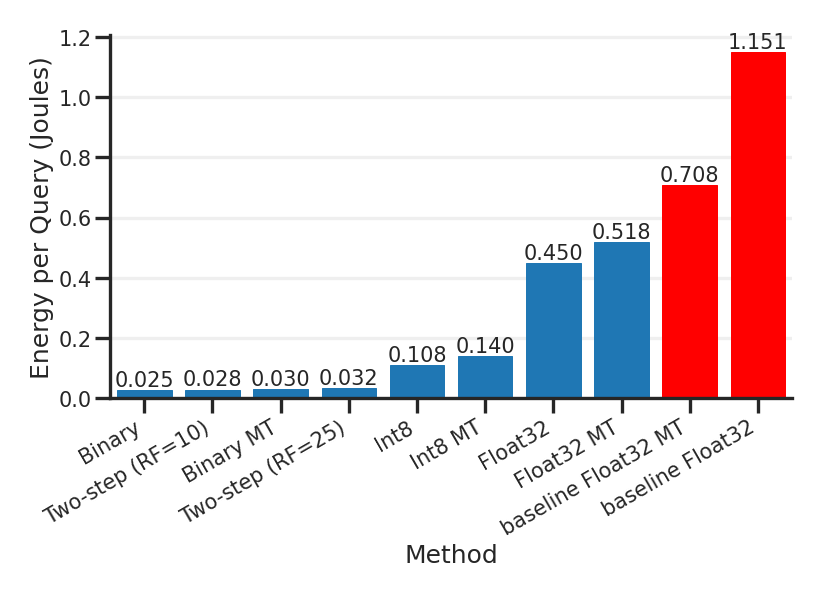

binary
twostep_rf10
binary_mt
twostep_rf25
int8
int8_mt
avx2
avx2_mt
float_mt
float


/tmp/ipykernel_62751/2073190063.py:113: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


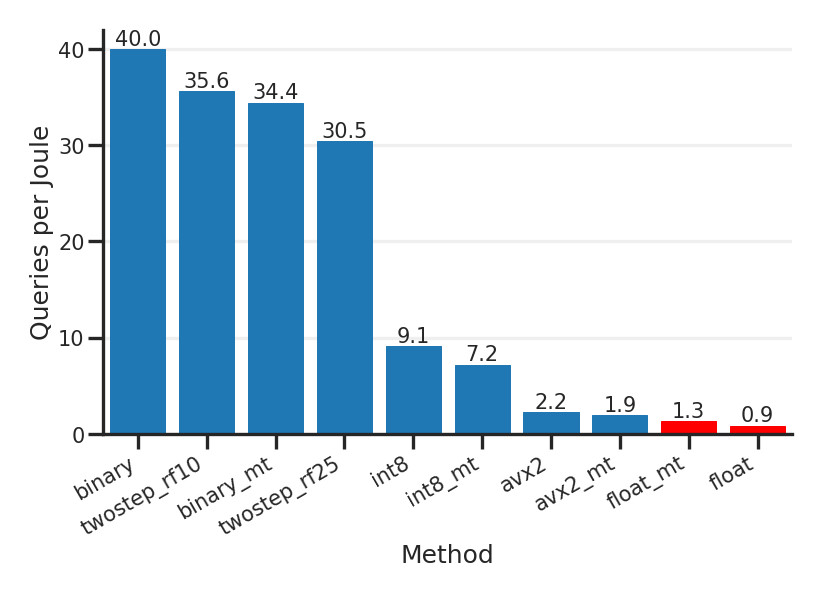

In [15]:
def plot_power_efficiency(results, result_key, skip_methods=None, display_mode='queries_per_joule',
                        method_names_map=None, enable_save_plot=False, name_postfix=""):
    """Create a plot showing power efficiency across methods.
    
    Args:
        results: Dictionary containing benchmark results
        result_key: Key of the benchmark results to plot
        skip_methods: List of method names to exclude from comparison
        display_mode: Either 'queries_per_joule' or 'joule_per_query' to control what value is displayed
        method_names_map: Dictionary mapping original method names to display names
        enable_save_plot: Whether to save the plot to disk
        name_postfix: Optional string to append to the filename
    """
    if skip_methods is None:
        skip_methods = []
        
    if method_names_map is None:
        method_names_map = {}
        
    if 'power_measurements' not in results[result_key]:
        print(f"No power measurements found in {result_key}")
        return
        
    # Collect efficiency data
    efficiency_data = []
    for method, measurements in results[result_key]['power_measurements'].items():
        if not any(fnmatch.fnmatch(method, pattern) for pattern in skip_methods):
            # Calculate energy metrics
            avg_power = measurements['summary']['avg_power']  # Watts
            avg_time_s = results[result_key]['summary'][method]['time_us']['mean'] / 1_000_000  # seconds
            energy_per_query = avg_power * avg_time_s  # Joules
            queries_per_joule = 1 / energy_per_query if energy_per_query > 0 else 0
            
            # Get display name from mapping or use original
            display_name = method_names_map.get(method, method)
            
            efficiency_data.append({
                'Method': method,
                'Display Name': display_name,
                'Queries per Joule': queries_per_joule,
                'Energy per Query (J)': energy_per_query,
                'NDCG': results[result_key]['summary'][method].get('ndcg', {}).get('mean', 1.0)
            })
    
    if not efficiency_data:
        print("No data to plot after filtering methods")
        return
        
    df = pd.DataFrame(efficiency_data)
    
    # Determine which metric to use based on display_mode
    if display_mode == 'joule_per_query':
        metric = 'Energy per Query (J)'
        y_label = 'Energy per Query (Joules)'
        title = 'Energy Consumption per Query'
        sort_ascending = True  # Lower is better for energy consumption
    else:  # default to queries_per_joule
        metric = 'Queries per Joule'
        y_label = 'Queries per Joule'
        title = 'Query Efficiency (Higher is Better)'
        sort_ascending = False  # Higher is better for queries per joule
    
    # Sort by the selected metric
    df = df.sort_values(metric, ascending=sort_ascending)
    
    fig, ax = plt.subplots(figsize=(2.75,2.0))
    
    # Plot using the display names instead of method names
    bars = sns.barplot(data=df, x='Display Name', y=metric, 
                     errorbar=None, ax=ax)
    
    # Define a function to determine color based on method name
    def get_color(method_name):
        # Example condition: highlight methods containing 'baseline'
        print(method_name.lower())
        if method_name.lower() in ['float', 'float_mt']:
            return 'red'
        else:
            return 'tab:blue'  # default color
    
    # Apply custom colors to each bar based on the method name
    for i, bar in enumerate(bars.patches):
        method_name = df.iloc[i]['Method']  # Get original method name
        bar.set_color(get_color(method_name))
    
    ax.set_xlabel('Method', fontsize=6)
    ax.set_ylabel(y_label, fontsize=6)
    #ax.set_title(title, fontsize=7)
    
    plt.xticks(rotation=30, ha='right', fontsize=5)
    plt.yticks(fontsize=5)
    
    # Add value labels on top of bars with appropriate formatting
    for bar in bars.containers[0]:
        height = bar.get_height()
        if display_mode == 'joule_per_query':
            # Format with more decimals for small energy values
            if height < 0.01:
                value_text = f'{height:.1e}'
            else:
                value_text = f'{height:.3f}'
        else:
            # Format queries per joule
            if height > 1000:
                value_text = f'{height/1000:.1f}k'
            else:
                value_text = f'{height:.1f}'
                
        ax.text(bar.get_x() + bar.get_width()/2., height,
              value_text, ha='center', va='bottom', fontsize=5)
        
    
    plt.tight_layout()
    
    if enable_save_plot:
        mode_text = 'joule_per_query' if display_mode == 'joule_per_query' else 'queries_per_joule'
        save_plot(f'power_efficiency_{mode_text}_{get_title_metadata(result_key=result_key, with_unterscores=True)}{name_postfix}')
    
    plt.show()

plot_power_efficiency(results, 'benchmark_results_arm1', skip_methods=['twostep_rf10_mt', 'twostep_rf25_mt'], enable_save_plot=False, display_mode='joule_per_query', method_names_map=DEFAULT_METHOD_NAMES)
plot_power_efficiency(results, 'benchmark_results_arm2', skip_methods=['twostep_rf10_mt', 'twostep_rf25_mt'])

Saved plot to ../../../bilder/plots/energy_vs_accuracy_results_arm1.pdf


/var/folders/9k/j19m8qg14sz78bs76g1lv5y80000gn/T/ipykernel_75983/3925107446.py:58: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


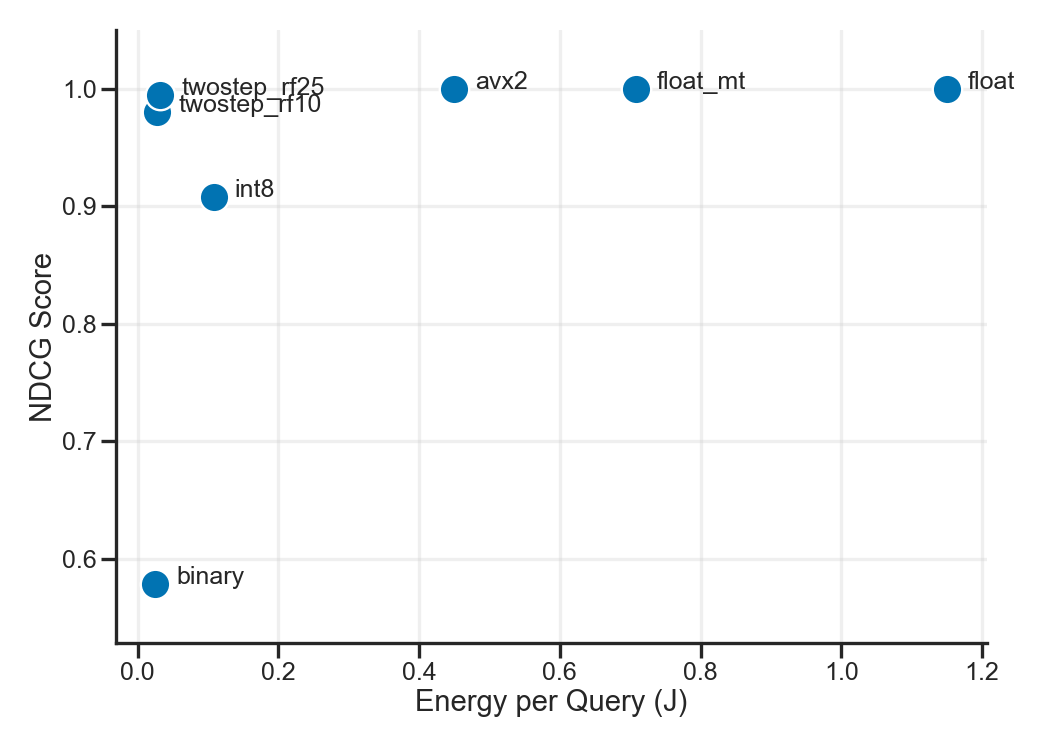

/var/folders/9k/j19m8qg14sz78bs76g1lv5y80000gn/T/ipykernel_75983/3925107446.py:58: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


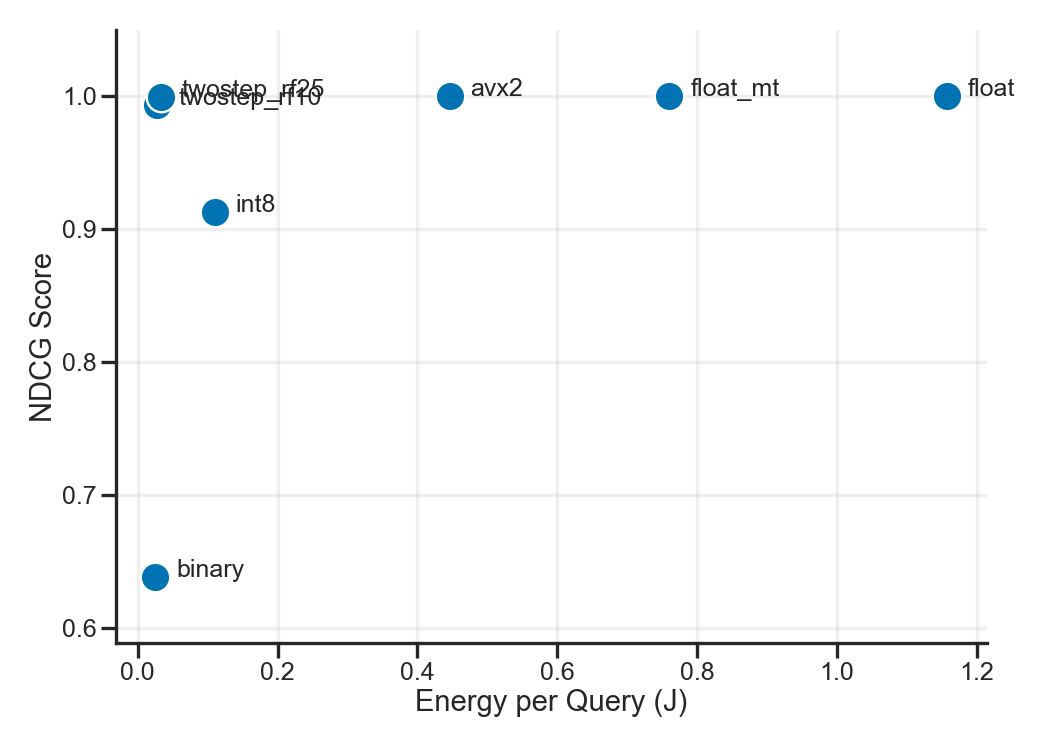

In [104]:
def plot_energy_accuracy_tradeoff(results, result_key, skip_methods=None, enable_save_plot=False, name_postfix=""):
    """Create a scatter plot showing the trade-off between energy consumption and search quality.
    
    Args:
        results: Dictionary containing benchmark results
        result_key: Key of the benchmark results to plot
        skip_methods: List of methods to exclude
        enable_save_plot: Whether to save the plot to disk
        name_postfix: Optional string to append to the filename
    """
    if skip_methods is None:
        skip_methods = []
        
    if 'power_measurements' not in results[result_key]:
        print(f"No power measurements found in {result_key}")
        return
        
    # Collect data
    plot_data = []
    
    for method, measurements in results[result_key]['power_measurements'].items():
        if not any(fnmatch.fnmatch(method, pattern) for pattern in skip_methods):
            # Correct calculation for energy per query
            avg_power = measurements['summary']['avg_power']  # Watts
            avg_time_s = results[result_key]['summary'][method]['time_us']['mean'] / 1_000_000  # seconds
            energy_per_query = avg_power * avg_time_s  # Joules
            
            ndcg = results[result_key]['summary'][method].get('ndcg', {}).get('mean', 1.0)
            
            plot_data.append({
                'Method': method,
                'Energy per Query (J)': energy_per_query,
                'NDCG': ndcg
            })
    
    df = pd.DataFrame(plot_data)
    
    fig, ax = plt.subplots()
    
    # Create scatter plot
    sns.scatterplot(data=df, x='Energy per Query (J)', y='NDCG', s=50, ax=ax)
    
    # Add method labels
    for _, row in df.iterrows():
        ax.annotate(row['Method'],
                  (row['Energy per Query (J)'], row['NDCG']),
                  xytext=(5, 0),
                  textcoords='offset points',
                  fontsize=6)
    
    #ax.set_title('Energy Consumption vs. Search Quality')
    ax.set_xlabel('Energy per Query (J)')
    ax.set_ylabel('NDCG Score')
    
    # Ensure NDCG axis shows reasonable range
    ax.set_ylim(max(0.5, df['NDCG'].min() - 0.05), 1.05)
    
    plt.tight_layout()
    
    if enable_save_plot:
        save_plot(f'energy_vs_accuracy_{get_title_metadata(result_key=result_key, with_unterscores=True)}{name_postfix}')
    
    plt.show()
    
plot_energy_accuracy_tradeoff(results, 'benchmark_results_arm1', skip_methods=['binary_mt', 'int8_mt', 'avx2_mt', 'twostep_rf10_mt', 'twostep_rf25_mt'], enable_save_plot=True)
plot_energy_accuracy_tradeoff(results, 'benchmark_results_arm2', skip_methods=['binary_mt', 'int8_mt', 'avx2_mt', 'twostep_rf10_mt', 'twostep_rf25_mt'])

In [ ]:
def export_plotly_plot(fig, filename_base="energy_ndcg_speed_plot", formats=None):
    """Export a Plotly figure in multiple formats.
    
    Args:
        fig: Plotly figure object
        filename_base: Base filename without extension
        formats: List of export formats. Default is ["html", "png", "svg"]
    """
    if formats is None:
        formats = ["html", "png", "svg"]
        
    for fmt in formats:
        try:
            if fmt.lower() == "html":
                fig.write_html(f"images/{filename_base}.html")
                print(f"Plot exported to {filename_base}.html")
            elif fmt.lower() == "json":
                import json
                with open(f"{filename_base}.json", 'w') as f:
                    json.dump(fig.to_dict(), f)
                print(f"Plot data exported to {filename_base}.json")
            elif fmt.lower() in ["png", "jpg", "jpeg", "svg", "pdf", "webp"]:
                try:
                    fig.write_image(f"{filename_base}.{fmt}")
                    print(f"Plot exported to {filename_base}.{fmt}")
                except Exception:
                    print(f"Error exporting to {fmt}. Make sure kaleido is installed: pip install kaleido")
            else:
                print(f"Unsupported format: {fmt}")
        except Exception as e:
            print(f"Error exporting to {fmt}: {str(e)}")


def plot_enhanced_3d_comparison(results, result_key, skip_methods=None, method_groups=None, export_formats=None, filename_base=None):
    """Create an enhanced interactive 3D scatter plot with improved readability.
    
    Args:
        results: Dictionary containing benchmark results
        result_key: Key of the benchmark results to plot
        skip_methods: List of methods to exclude
        method_groups: Dictionary mapping method groups to their methods for coloring
        export_formats: List of formats to export the plot
        filename_base: Base filename for exports
    """
    try:
        import plotly.express as px
        import plotly.graph_objects as go
        from plotly.subplots import make_subplots
    except ImportError:
        print("Plotly not installed. Install with: pip install plotly")
        return
    
    if skip_methods is None:
        skip_methods = []
        
    if method_groups is None:
        # Default grouping by method type
        method_groups = {
            "Float": ["float", "float_mt"],
            "AVX2": ["avx2", "avx2_mt"],
            "Binary": ["binary", "binary_mt"],
            "Int8": ["int8", "int8_mt"],
            "Two-Step": ["twostep_rf10", "twostep_rf25", "twostep_rf10_mt", "twostep_rf25_mt"]
        }
        
    # If no filename base is provided, generate one
    if filename_base is None:
        filename_base = f"enhanced_3d_plot_{get_title_metadata(result_key=result_key, with_unterscores=True)}"
        
    if 'power_measurements' not in results[result_key]:
        print(f"No power measurements found in {result_key}")
        return
        
    # Collect data
    plot_data = []
    
    for method, measurements in results[result_key]['power_measurements'].items():
        if not any(fnmatch.fnmatch(method, pattern) for pattern in skip_methods):
            # Calculate energy per query
            avg_power = measurements['summary']['avg_power']  # Watts
            avg_time_ms = results[result_key]['summary'][method]['time_us']['mean'] / 1000  # milliseconds
            avg_time_s = avg_time_ms / 1000  # seconds
            energy_per_query = avg_power * avg_time_s  # Joules
            
            ndcg = results[result_key]['summary'][method].get('ndcg', {}).get('mean', 0.95)
            
            # Assign group
            group = "Other"
            for group_name, group_methods in method_groups.items():
                if any(fnmatch.fnmatch(method, pattern) for pattern in group_methods):
                    group = group_name
                    break
            
            plot_data.append({
                'Method': method,
                'Energy per Query (J)': energy_per_query,
                'Query Time (ms)': avg_time_ms,
                'NDCG': ndcg,
                'Group': group,
                
                # Add detailed hover text
                'Details': (f"Method: {method}<br>"
                           f"Energy: {energy_per_query:.6f} J<br>"
                           f"Time: {avg_time_ms:.2f} ms<br>"
                           f"NDCG: {ndcg:.4f}")
            })
    
    if not plot_data:
        print("No data to plot after filtering methods")
        return
        
    df = pd.DataFrame(plot_data)
    
    # Create subplots: 3D scatter and 2D projections
    fig = make_subplots(
        rows=2, cols=2,
        specs=[[{'type': 'scene', 'rowspan': 2, 'colspan': 1}, {'type': 'xy'}],
               [None, {'type': 'xy'}]],
        subplot_titles=["3D Visualization", "Time vs Energy Projection", "NDCG vs Energy Projection"],
        vertical_spacing=0.1,
        horizontal_spacing=0.05
    )
    
    # Color mapping for method groups
    colors = px.colors.qualitative.Plotly
    color_map = {group: colors[i % len(colors)] for i, group in enumerate(method_groups.keys())}
    color_map["Other"] = "#999999"  # Gray for "Other" category
    
    # Add 3D scatter plot with better aesthetics
    for group_name in method_groups.keys():
        group_df = df[df['Group'] == group_name]
        if len(group_df) > 0:
            fig.add_trace(
                go.Scatter3d(
                    x=group_df['Query Time (ms)'],
                    y=group_df['Energy per Query (J)'],
                    z=group_df['NDCG'],
                    mode='markers+text',
                    marker=dict(
                        size=8,
                        color=color_map[group_name],
                        symbol='circle',
                        opacity=0.8,
                        line=dict(color='black', width=1.0)
                    ),
                    text=group_df['Method'],
                    textposition="top center",
                    textfont=dict(size=12, color=color_map[group_name]),
                    hovertext=group_df['Details'],
                    hoverinfo='text',
                    name=group_name
                ),
                row=1, col=1
            )
    
    # Add reference planes for better orientation
    min_time = df['Query Time (ms)'].min() * 0.8
    max_time = df['Query Time (ms)'].max() * 1.2
    min_energy = df['Energy per Query (J)'].min() * 0.8
    max_energy = df['Energy per Query (J)'].max() * 1.2
    min_ndcg = 0.55  # Fixed low value for better visibility
    max_ndcg = 1.0125 # Slightly above 1.0 for better visibility
    
    # Add a semitransparent plane at the minimum NDCG value (floor)
    x_grid, y_grid = np.meshgrid(
        np.linspace(min_time, max_time, 2),
        np.linspace(min_energy, max_energy, 2)
    )
    z_grid = np.full_like(x_grid, min_ndcg)
    
    fig.add_trace(
        go.Surface(
            x=x_grid, y=y_grid, z=z_grid,
            colorscale=[[0, 'rgba(200, 200, 200, 0.2)'], [1, 'rgba(200, 200, 200, 0.2)']],
            showscale=False,
            name='NDCG Floor'
        ),
        row=1, col=1
    )
    
    # Add lines dropping from each point to the floor
    for _, row in df.iterrows():
        fig.add_trace(
            go.Scatter3d(
                x=[row['Query Time (ms)'], row['Query Time (ms)']],
                y=[row['Energy per Query (J)'], row['Energy per Query (J)']],
                z=[row['NDCG'], min_ndcg],
                mode='lines',
                line=dict(color='rgba(140, 140, 140, 0.4)', width=2, dash='dash'),
                showlegend=False
            ),
            row=1, col=1
        )
    
    # Add ideal corner marker with clearer visibility
    ideal_x = min(df['Query Time (ms)']) * 0.9
    ideal_y = min(df['Energy per Query (J)']) * 0.9
    ideal_z = 1.0
    
    fig.add_trace(
        go.Scatter3d(
            x=[ideal_x],
            y=[ideal_y],
            z=[ideal_z],
            mode='markers+text',
            marker=dict(size=3, color='red', symbol='x', opacity=0.9),
            text=['IDEAL'],
            textposition="top center",
            textfont=dict(size=12, color='red'),
            name='Ideal Point'
        ),
        row=1, col=1
    )
    
    # Add Pareto-optimal front calculation
    pareto_points = []
    for i, row_i in df.iterrows():
        is_pareto = True
        for j, row_j in df.iterrows():
            if i != j:
                # For NDCG, higher is better
                if (row_j['Query Time (ms)'] <= row_i['Query Time (ms)'] and 
                    row_j['Energy per Query (J)'] <= row_i['Energy per Query (J)'] and 
                    row_j['NDCG'] >= row_i['NDCG']):
                    
                    # At least one dimension must be strictly better
                    if (row_j['Query Time (ms)'] < row_i['Query Time (ms)'] or 
                        row_j['Energy per Query (J)'] < row_i['Energy per Query (J)'] or
                        row_j['NDCG'] > row_i['NDCG']):
                        
                        is_pareto = False
                        break
        
        if is_pareto:
            pareto_points.append(row_i)
    
    # Add Pareto-optimal points with special highlighting
    pareto_x = [p['Query Time (ms)'] for p in pareto_points]
    pareto_y = [p['Energy per Query (J)'] for p in pareto_points]
    pareto_z = [p['NDCG'] for p in pareto_points]
    
    if pareto_points:
        fig.add_trace(
            go.Scatter3d(
                x=pareto_x,
                y=pareto_y,
                z=pareto_z,
                mode='markers',
                marker=dict(
                    size=12,
                    color='rgba(0,0,0,0)',
                    line=dict(color='yellow', width=3),
                    symbol='circle'
                ),
                name='Pareto Optimal',
                hoverinfo='skip'
            ),
            row=1, col=1
        )
    
    # Add 2D projections
    # Time vs Energy
    for group_name in method_groups.keys():
        group_df = df[df['Group'] == group_name]
        if len(group_df) > 0:
            fig.add_trace(
                go.Scatter(
                    x=group_df['Query Time (ms)'],
                    y=group_df['Energy per Query (J)'],
                    mode='markers+text',
                    marker=dict(size=12, color=color_map[group_name]),
                    text=group_df['Method'],
                    textposition="top right",
                    textfont=dict(size=12),
                    hovertext=group_df['Details'],
                    hoverinfo='text',
                    name=group_name,
                    showlegend=False
                ),
                row=1, col=2
            )
    
    # NDCG vs Energy
    for group_name in method_groups.keys():
        group_df = df[df['Group'] == group_name]
        if len(group_df) > 0:
            fig.add_trace(
                go.Scatter(
                    x=group_df['Energy per Query (J)'],
                    y=group_df['NDCG'],
                    mode='markers+text',
                    marker=dict(size=12, color=color_map[group_name]),
                    text=group_df['Method'],
                    textposition="top right",
                    textfont=dict(size=12),
                    hovertext=group_df['Details'],
                    hoverinfo='text',
                    name=group_name,
                    showlegend=False
                ),
                row=2, col=2
            )
    
    # Update 3D layout
    fig.update_scenes(
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=1),
        xaxis=dict(title='Query Time (ms)', showgrid=True, gridcolor='rgba(150,150,150,0.2)'),
        yaxis=dict(title='Energy per Query (J)', showgrid=True, gridcolor='rgba(150,150,150,0.2)'),
        zaxis=dict(
            title='NDCG Score',
            range=[min_ndcg, max_ndcg],
            showgrid=True,
            gridcolor='rgba(150,150,150,0.2)'
        ),
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=0.8),  # Adjusted camera position
            up=dict(x=0, y=0, z=1)
        )
    )
    
    # Update 2D projection layouts
    fig.update_xaxes(title_text='Query Time (ms)', row=1, col=2)
    fig.update_yaxes(title_text='Energy per Query (J)', row=1, col=2)
    
    fig.update_xaxes(title_text='Energy per Query (J)', row=2, col=2)
    fig.update_yaxes(title_text='NDCG Score', row=2, col=2)
    fig.update_yaxes(range=[min_ndcg, max_ndcg], row=2, col=2)
    
    # Update overall layout
    fig.update_layout(
        title='Enhanced 3D Comparison of Energy, Performance, and Search Quality',
        legend_title='Method Groups',
        height=1200,  # Taller figure for clarity
        width=2400,   # Wider figure to accommodate projections
        margin=dict(l=60, r=20, t=80, b=60),
    )
    
    # Add buttons for predefined views
    camera_views = dict(
        Front=dict(eye=dict(x=1.5, y=1.5, z=0.8)),
        Top=dict(eye=dict(x=0.1, y=0.1, z=2.5)),
        TimeEnergy=dict(eye=dict(x=0.1, y=0.1, z=0.1)),
        TimeNDCG=dict(eye=dict(x=0.1, y=2.5, z=0.1)),
        EnergyNDCG=dict(eye=dict(x=2.5, y=0.1, z=0.1))
    )
    
    fig.update_layout(
        updatemenus=[
            dict(
                type='buttons',
                direction='right',
                buttons=[
                    dict(
                        args=[{'scene.camera.eye': eye}],
                        label=name,
                        method='relayout'
                    ) for name, eye in camera_views.items()
                ],
                pad={"r": 10, "t": 10},
                showactive=True,
                x=0.05,
                xanchor="left",
                y=1.15,
                yanchor="top"
            )
        ]
    )
    
    # Add helpful annotations
    fig.add_annotation(
        x=0.5, y=1.08,
        xref="paper", yref="paper",
        text="Tip: Use the view buttons to see different perspectives",
        showarrow=False,
        font=dict(size=12, color="darkblue"),
        align="center"
    )
    
    # Export the plot if formats are specified
    if export_formats:
        export_plotly_plot(fig, filename_base=filename_base, formats=export_formats)
    
    # fig.show()
    
    return fig  # Return the figure for further manipulation if needed

plot_enhanced_3d_comparison(results, 'benchmark_results_arm1', skip_methods=['twostep_rf10_mt', 'twostep_rf25_mt'], export_formats=["html"], filename_base="3d_plot_arm1")

['Float32', 'Binary', 'Int8', 'Float16', 'Mapped Float', 'PCA (/2)', 'PCA (/4)', 'PCA (/8)', 'PCA (/32)', 'Two-step (RF=2)', 'Two-step (RF=50)', 'Two-step MF (RF=2)', 'Two-step MF (RF=50)']
Saved plot to ../../../bilder/plots/benchmark_comparison_dim1024_k100_q_dim768_k100_q.pdf


/var/folders/9k/j19m8qg14sz78bs76g1lv5y80000gn/T/ipykernel_75983/2214411968.py:76: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


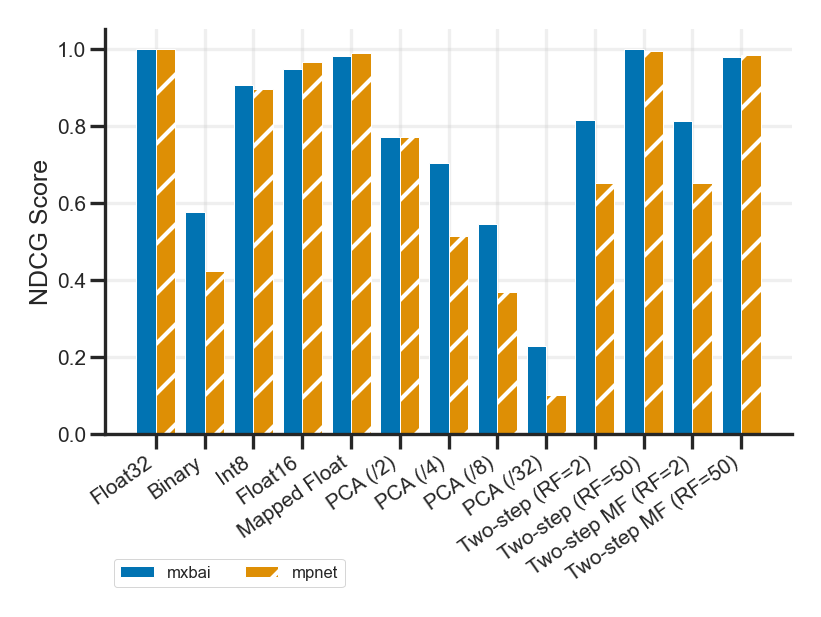

In [115]:
def compare_benchmarks(results_dict, benchmark_keys, names=None, skip_methods=['float'], enable_save_plot=False, name_postfix="", plot_title='NDCG Comparison Across Embedding Models', method_names_map=None):
    """Compare NDCG scores across multiple benchmark results.
    
    Args:
        results_dict: Dictionary containing multiple benchmark results
        benchmark_keys: List of benchmark result keys to compare
        names: Optional list of names to use for the benchmarks (e.g. 'BERT-1024', 'BERT-768')
        skip_methods: List of methods to exclude from comparison
    """
    if names is None:
        names = benchmark_keys
        
    if len(benchmark_keys) != len(names):
        raise ValueError("Length of benchmark_keys and names must match")
    
    # Collect metadata and basic statistics for each benchmark
    benchmark_info = {}
    for key, name in zip(benchmark_keys, names):
        # Get basic statistics for each method
        method_stats = {}
        
        if method_names_map is None:
            method_names_map = DEFAULT_METHOD_NAMES
            
        for method, stats in results_dict[key]['summary'].items():
            if method not in skip_methods:
                display_name = get_method_display_name(method, method_names_map)
                method_stats[display_name] = {
                    'mean_time': stats['time_us']['mean'],
                    'std_time': stats['time_us']['std'],
                    'ndcg': stats.get('ndcg', {}).get('mean', 1.0),
                    'ndcg_std': stats.get('ndcg', {}).get('std', 0.0),
                }
            
        benchmark_info[name] = {
            'metadata': results_dict[key]['metadata'],
            'stats': method_stats
        }
    
    # Prepare data for plotting
    methods = list(benchmark_info[names[0]]['stats'].keys())
    print(methods)
    methods_filtered = [m for m in methods if m not in skip_methods]
    methods_filtered = [m for m in methods if not any(fnmatch.fnmatch(m, pattern) for pattern in skip_methods)]
    x = np.arange(len(methods_filtered))
    width = 0.8 / len(names)  # Width of bars
    
    # Create NDCG comparison plot
    plt.figure(figsize=(2.75, 2.25))
    hatch_styles = ["", "//"]
    
    # Plot bars for each benchmark
    for i, name in enumerate(names):
        ndcg_scores = [benchmark_info[name]['stats'][method]['ndcg'] 
                      for method in methods_filtered]
        
        plt.bar(x + i*width - width*len(names)/2 + width/2,
                ndcg_scores,
                width,
                label=name,
                hatch=hatch_styles[i])

    # plt.xlabel('Methods', fontsize=6)
    plt.ylabel('NDCG Score', fontsize=6)
    #plt.title(plot_title, fontsize=7)
    plt.xticks(x, methods_filtered, rotation=35, ha='right', fontsize=5)
    plt.yticks(fontsize=5)
    # plt.legend(loc=3, ncol=1, bbox_to_anchor=(-0,-0.4), fontsize=4, ['mxbai', 'mpnet'])

    handles, _ = plt.gca().get_legend_handles_labels()
    plt.legend(handles, ['mxbai', 'mpnet'],
            loc=3, ncol=2, bbox_to_anchor=(-0,-0.4), fontsize=4)

    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save plot if enabled
    if len(benchmark_keys) > 1:
        if enable_save_plot: save_plot(f'benchmark_comparison_{get_title_metadata(result_key=benchmark_keys[0], with_unterscores=True)}_{get_title_metadata(result_key=benchmark_keys[1], with_unterscores=True)}{name_postfix}')
    else:
        if enable_save_plot: save_plot(f'benchmark_comparison_{get_title_metadata(result_key=benchmark_keys[0], with_unterscores=True)}{name_postfix}')
    
    plt.show()
    
    # Print detailed comparison
    # print("\nDetailed Comparison:")
    # for method in methods:
    #     print(f"\nMethod: {method}")
    #     print("-" * 50)
    #     for name in names:
    #         stats = benchmark_info[name]['stats'][method]
    #         dim = benchmark_info[name]['metadata']['vector_dim']
    #         print(f"{name} (dim={dim}):")
    #         print(f"  Time: {stats['mean_time']:.2f} ± {stats['std_time']:.2f} μs")
    #         if method != 'float':
    #             print(f"  NDCG: {stats['ndcg']:.3f} ± {stats['ndcg_std']:.3f}")

# Example usage with multiple benchmark results
# print(results['benchmark_dim1024_k10_q']['summary'].keys())
compare_benchmarks(results, 
                   benchmark_keys=['benchmark_dim1024_k100_q', 'benchmark_dim768_k100_q'],
                   names=['mxbai-embed-large-v1', 'all-mpnet-base-v2'],
                   skip_methods=['float', 'twostep_rf5', 'twostep_rf10', 'twostep_rf25','pca16', 'ts_mf_rf5', 'ts_mf_rf10', 'ts_mf_rf25'], enable_save_plot=True)
# compare_benchmarks(results, 
#                    benchmark_keys=['benchmark_dim1024_k100_re', 'benchmark_dim768_k100_re'],
#                    names=['mxbai-embed-large-v1', 'all-mpnet-base-v2'],
#                    skip_methods=['float'])